In [1]:
import numpy as np
import os

gt = np.load("model_comparison/ground_truth.npy")
mask = np.load("./data/oisst_spatial_mask_ecs.npy") 

In [2]:
import numpy as np
import pandas as pd
import os

def calculate_global_rmse(preds, gt, mask):
    """
    모든 샘플을 통째로 연산하여 Global RMSE를 산출합니다.
    """
    # 1. 오차 제곱 계산 (N, T, C, H, W)
    diff2 = (preds - gt) ** 2
    
    # 2. 마스크 준비 및 브로드캐스팅
    # mask: (32, 32) -> (1, 1, 1, 32, 32)
    m = mask[None, None, None, :, :]
    
    # 3. 바다 영역(mask==1)인 지점의 오차 제곱합과 유효 픽셀 수 계산
    # np.nansum을 사용하여 혹시 모를 NaN 값 방지
    sum_sq_error = np.nansum(diff2 * m)
    total_valid_pixels = np.sum(m) * preds.shape[0] * preds.shape[1] * preds.shape[2]
    
    # 4. Global MSE -> RMSE
    global_mse = sum_sq_error / total_valid_pixels
    global_rmse = np.sqrt(global_mse)
    
    return global_rmse

# --- 실행부 ---
gt = np.load("model_comparison/ground_truth.npy")
mask = np.load("data/oisst_spatial_mask_ecs.npy")

model_names = [

    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU"
]

results = []
for name in model_names:
    path = f"model_comparison/{name}_preds.npy"
    if os.path.exists(path):
        preds = np.load(path)
        
        # Global 방식 적용
        g_rmse = calculate_global_rmse(preds, gt, mask)
        results.append({"Model": name, "Global_RMSE": g_rmse})

# 결과 출력
df_global_rank = pd.DataFrame(results).sort_values("Global_RMSE")
print("=== Final Global Performance Ranking ===")
print(df_global_rank)

=== Final Global Performance Ranking ===
          Model  Global_RMSE
2  msfv3_base03     0.109727
6       ViT_GRU     0.112520
3       predrnn     0.115014
1           MIM     0.115430
0      ConvLSTM     0.118589
4    simvp_gsta     0.121886
5  SimVP_INCEPU     0.130892


In [3]:
import numpy as np
import pandas as pd
import os

def denorm_zscore(x, mean, std):
    return x * std + mean

def calculate_global_metrics(preds, gt, mask, eps=1e-6):
    """
    preds, gt: (N, T, C, H, W)
    mask: (H, W) with 1 for valid ocean pixels, 0 for invalid pixels
    """
    m = mask[None, None, None, :, :]  # (1,1,1,H,W)

    diff = preds - gt
    diff2 = diff ** 2
    abs_diff = np.abs(diff)

    total_valid = np.sum(m) * preds.shape[0] * preds.shape[1] * preds.shape[2]

    # RMSE
    global_mse = np.nansum(diff2 * m) / total_valid
    global_rmse = np.sqrt(global_mse)

    # MAE
    global_mae = np.nansum(abs_diff * m) / total_valid

    # MAPE
    denom = np.clip(np.abs(gt), eps, None)
    ape = (abs_diff / denom) * m
    global_mape = np.nansum(ape) / total_valid * 100.0

    return {
        "Global_RMSE": global_rmse,
        "Global_MAE": global_mae,
        "Global_MAPE": global_mape,
    }


# --- 실행부 ---
gt = np.load("model_comparison/ground_truth.npy")
mask = np.load("data/oisst_spatial_mask_ecs.npy").astype(np.float32)

model_names = [
    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU",
    "swinLstm_B"
]


USE_DENORM = True

# =========================
# 경우 2: z-score 정규화 상태면 mean/std 넣기
# =========================
mean = 22.5081844329834
std  = 4.8933515548706055

results = []

for name in model_names:
    path = f"model_comparison/{name}_preds.npy"
    if not os.path.exists(path):
        continue

    preds = np.load(path)

    if USE_DENORM:
        preds_eval = denorm_zscore(preds, mean, std)
        gt_eval = denorm_zscore(gt, mean, std)
    else:
        preds_eval = preds
        gt_eval = gt

    metrics = calculate_global_metrics(preds_eval, gt_eval, mask, eps=1e-6)
    results.append({
        "Model": name,
        **metrics
    })

df = pd.DataFrame(results).sort_values("Global_RMSE").reset_index(drop=True)
print("=== Final Global Performance Ranking ===")
print(df)

=== Final Global Performance Ranking ===
          Model  Global_RMSE  Global_MAE  Global_MAPE
0  msfv3_base03     0.536931    0.380283     1.748776
1       ViT_GRU     0.550601    0.392176     1.820175
2       predrnn     0.562803    0.398739     1.819979
3    swinLstm_B     0.564263    0.404829     1.866705
4           MIM     0.564842    0.403984     1.841365
5      ConvLSTM     0.580295    0.411936     1.883885
6    simvp_gsta     0.596430    0.432398     1.961532
7  SimVP_INCEPU     0.640498    0.473784     2.186922


In [4]:
import numpy as np
import pandas as pd
import os

# --- 실행부 ---
gt = np.load("model_comparison/ground_truth.npy")
mask = np.load("data/oisst_spatial_mask_ecs.npy")

model_names = [
    "ConvLSTM",
    "MAU",
    "MIM",

    "msfv3_base03",
    "msfv3_gdl01",
    "msfv3_gdl03",
    "msfv3_gdl05",
    "msfv3_gdl10",
    "msfv3_lk",
    "msfv3_lk03",

    "msfv4_base",

    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU"
]

results = []
for name in model_names:
    path = f"model_comparison/{name}_preds.npy"
    if os.path.exists(path):
        preds = np.load(path)
        
        # Global 방식 적용
        g_rmse = calculate_global_rmse(preds, gt, mask)
        results.append({"Model": name, "Global_RMSE": g_rmse})

# 결과 출력
df_global_rank = pd.DataFrame(results).sort_values("Global_RMSE")
print("=== Final Global Performance Ranking ===")
print(df_global_rank)

=== Final Global Performance Ranking ===
           Model  Global_RMSE
5    msfv3_gdl03     0.108201
4    msfv3_gdl01     0.108754
6    msfv3_gdl05     0.108872
7    msfv3_gdl10     0.109598
3   msfv3_base03     0.109727
10    msfv4_base     0.110301
9     msfv3_lk03     0.111210
8       msfv3_lk     0.111650
1            MAU     0.111863
14       ViT_GRU     0.112520
11       predrnn     0.115014
2            MIM     0.115430
0       ConvLSTM     0.118589
12    simvp_gsta     0.121886
13  SimVP_INCEPU     0.130892


In [5]:
import pandas as pd
import numpy as np

start_date = "2016-01-15"
num_samples = 1792

# 2. 날짜 시퀀스 생성 (하루 단위)
date_indices = pd.date_range(start=start_date, periods=num_samples, freq='D')

# 3. 각 날짜에서 '월' 정보 추출
all_meta_months = date_indices.month.values

print(f"Generated metadata for {num_samples} samples.")
print(f"First sample month: {all_meta_months[0]} ({date_indices[0].date()})")
print(f"Last sample month: {all_meta_months[-1]} ({date_indices[-1].date()})")

Generated metadata for 1792 samples.
First sample month: 1 (2016-01-15)
Last sample month: 12 (2020-12-10)


In [6]:
model_names = [

    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU",
    "swinLstm_B"
    
]

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) 설정
# =========================
PRED_DIR = "model_comparison"
GT_PATH = os.path.join(PRED_DIR, "ground_truth.npy")
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"

# preds 파일명 규칙: {name}_preds.npy

model_names = [

    "ConvLSTM",
    "MAU",
    "MIM",

    "msfv3_base03",
    "msfv3_gdl01",
    "msfv3_gdl03",
    "msfv3_gdl05",
    "msfv3_gdl10",
    "msfv3_lk",
    "msfv3_lk03",

    "msfv4_base",

    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU"
]

VIS_MODELS = model_names 

# qualitative(시각화) 샘플 인덱스들
SAMPLE_IDXS = [20,]  # 원하는 대로 바꿔도 됨

# 그림 저장 옵션
SAVE_FIGS = True
FIG_DIR = "model_comparison/figs"
os.makedirs(FIG_DIR, exist_ok=True)


# =========================
# 1) 유틸
# =========================
def load_mask(mask_path):
    mask = np.load(mask_path)
    # bool 또는 0/1로 정리
    if mask.dtype != np.bool_:
        # 값이 0/1이라고 가정하고 bool로 변환
        mask = (mask > 0)
    return mask

def apply_mask_nan(x, mask_hw):
    """
    x: (..., H, W) or (..., C, H, W) where C==1
    mask_hw: (H,W) bool, True=valid(ocean)
    return: masked array with land -> NaN (for visualization)
    """
    m = mask_hw.astype(bool)
    # x가 (..., 1, H, W)면 channel 축 제거해서 처리할 수도 있음
    x = x.copy()
    if x.ndim >= 3 and x.shape[-3] == 1:
        # (..., 1, H, W)
        land = ~m
        x[..., 0, land] = np.nan
    else:
        land = ~m
        x[..., land] = np.nan
    return x

def global_rmse_and_rmse_t(preds, gt, mask_hw):
    """
    preds, gt: (N, T, C, H, W)
    mask_hw: (H,W) bool
    return:
      rmse_global: float
      rmse_t: (T,) np.array
    """
    m = mask_hw.astype(np.float32)[None, None, None, :, :]  # (1,1,1,H,W)
    diff2 = (preds - gt) ** 2
    diff2 = np.nan_to_num(diff2, nan=0.0)

    # global
    sum_sq = np.sum(diff2 * m)
    count = np.sum(m) * preds.shape[0] * preds.shape[1] * preds.shape[2]
    rmse_global = np.sqrt(sum_sq / count)

    # per lead time
    sum_sq_t = np.sum(diff2 * m, axis=(0, 2, 3, 4))  # (T,)
    count_t = np.sum(mask_hw) * preds.shape[0] * preds.shape[2]
    rmse_t = np.sqrt(sum_sq_t / count_t)

    return rmse_global, rmse_t

def safe_load_preds(model_name):
    path = os.path.join(PRED_DIR, f"{model_name}_preds.npy")
    if not os.path.exists(path):
        print(f"[skip] missing: {path}")
        return None
    return np.load(path)

def infer_vmin_vmax(gt_sample, mask_hw, percentile=(2, 98)):
    """
    gt_sample: (T,1,H,W)
    """
    x = apply_mask_nan(gt_sample, mask_hw)
    vals = x.reshape(-1)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return None, None
    lo = np.percentile(vals, percentile[0])
    hi = np.percentile(vals, percentile[1])
    return float(lo), float(hi)


# =========================
# 2) (A) 모델별 Horizon Curve (1~7일) + 표 저장
# =========================
gt = np.load(GT_PATH)  # (N,T,C,H,W)
mask_hw = load_mask(MASK_PATH)

T = gt.shape[1]
lead_days = np.arange(1, T + 1)

rows = []
rmse_t_dict = {}

for name in model_names:
    preds = safe_load_preds(name)
    if preds is None:
        continue
    rmse_global, rmse_t = global_rmse_and_rmse_t(preds, gt, mask_hw)
    rmse_t_dict[name] = rmse_t
    row = {"Model": name, "Global_RMSE": rmse_global}
    for i, v in enumerate(rmse_t, start=1):
        row[f"RMSE_t{i}"] = float(v)
    rows.append(row)

df = pd.DataFrame(rows).sort_values("Global_RMSE").reset_index(drop=True)
# =========================
# (A') Global RMSE & RMSE_t 표를 "월별표 스타일"로 보기 좋게 변환
#     - 행: Global, D1..DT
#     - 열: Model
#     - 각 행에서 최솟값(=best)만 강조
# =========================

# df: columns = ["Model","Global_RMSE","RMSE_t1"...]
metrics = ["Global_RMSE"] + [c for c in df.columns if c.startswith("RMSE_t")]

# (행=지표/리드타임, 열=모델)로 뒤집기
df_pivot2 = df.set_index("Model")[metrics].T

# 보기 좋게 인덱스 이름 바꾸기
new_index = ["Global"] + [f"D{i}" for i in range(1, len(df_pivot2.index))]
df_pivot2.index = new_index

df_pivot2_round = df_pivot2.round(6)

def highlight_best_row(s):
    is_min = s == s.min()
    return ['color: #ff3b30; font-weight: bold' if v else '' for v in is_min]

styled_table2 = (
    df_pivot2_round.style
    .apply(highlight_best_row, axis=1)   # 월별표랑 동일하게 "행 기준" 최솟값 강조
    .format("{:.6f}")
)

display(styled_table2)

# CSV 저장
out_csv = os.path.join(FIG_DIR, "global_rmse_and_rmse_t.csv")
df.to_csv(out_csv, index=False)
print(f"[saved] {out_csv}")




Model,msfv3_gdl03,msfv3_gdl01,msfv3_gdl05,msfv3_gdl10,msfv3_base03,msfv4_base,msfv3_lk03,msfv3_lk,MAU,ViT_GRU,predrnn,MIM,ConvLSTM,simvp_gsta,SimVP_INCEPU
Global,0.108201,0.108754,0.108872,0.109598,0.109727,0.110301,0.111210,0.111650,0.111863,0.112520,0.115014,0.115430,0.118589,0.121886,0.130892
D1,0.047465,0.047581,0.046867,0.046455,0.048880,0.048173,0.048429,0.053826,0.054010,0.057025,0.051661,0.052211,0.054119,0.085581,0.097447
D2,0.075616,0.076484,0.075847,0.075449,0.078209,0.078057,0.077004,0.080775,0.080076,0.081093,0.081458,0.082084,0.084040,0.098491,0.110243
D3,0.095795,0.096756,0.096287,0.096260,0.097810,0.097594,0.097866,0.099745,0.099620,0.099946,0.102766,0.102842,0.105516,0.112660,0.122483
D4,0.110979,0.111388,0.111592,0.112129,0.112004,0.111937,0.113613,0.113605,0.114250,0.114934,0.118150,0.118549,0.121628,0.122760,0.132191
D5,0.122739,0.123152,0.123891,0.124669,0.124012,0.124596,0.126347,0.125610,0.126598,0.126827,0.130093,0.130707,0.134173,0.133620,0.140591
D6,0.132659,0.133119,0.133658,0.135043,0.133993,0.135265,0.137635,0.135810,0.136700,0.136510,0.140241,0.140770,0.144640,0.140227,0.148947
D7,0.140803,0.141500,0.141723,0.143576,0.142579,0.144483,0.144588,0.144086,0.143432,0.144494,0.148934,0.149248,0.153626,0.147269,0.154439


[saved] model_comparison/figs/global_rmse_and_rmse_t.csv


Model,msfv3_gdl03,msfv3_gdl01,msfv3_gdl07,msfv3_gdl05,msfv3_gdl10,msfv3_base03,MAU,ViT_GRU,predrnn,MIM,ConvLSTM,simvp_gsta,SimVP_INCEPU
Global,0.108201,0.108754,0.108870,0.108872,0.109598,0.109727,0.111863,0.112520,0.115014,0.115430,0.118589,0.121886,0.130892
D1,0.047465,0.047581,0.046564,0.046867,0.046455,0.048880,0.054010,0.057025,0.051661,0.052211,0.054119,0.085581,0.097447
D2,0.075616,0.076484,0.075693,0.075847,0.075449,0.078209,0.080076,0.081093,0.081458,0.082084,0.084040,0.098491,0.110243
D3,0.095795,0.096756,0.096109,0.096287,0.096260,0.097810,0.099620,0.099946,0.102766,0.102842,0.105516,0.112660,0.122483
D4,0.110979,0.111388,0.111453,0.111592,0.112129,0.112004,0.114250,0.114934,0.118150,0.118549,0.121628,0.122760,0.132191
D5,0.122739,0.123152,0.123998,0.123891,0.124669,0.124012,0.126598,0.126827,0.130093,0.130707,0.134173,0.133620,0.140591
D6,0.132659,0.133119,0.133801,0.133658,0.135043,0.133993,0.136700,0.136510,0.140241,0.140770,0.144640,0.140227,0.148947
D7,0.140803,0.141500,0.141896,0.141723,0.143576,0.142579,0.143432,0.144494,0.148934,0.149248,0.153626,0.147269,0.154439


[saved] model_comparison/figs/global_rmse_and_rmse_t.csv
[saved] model_comparison/figs/global_rmse_and_rmse_t_pivot.csv


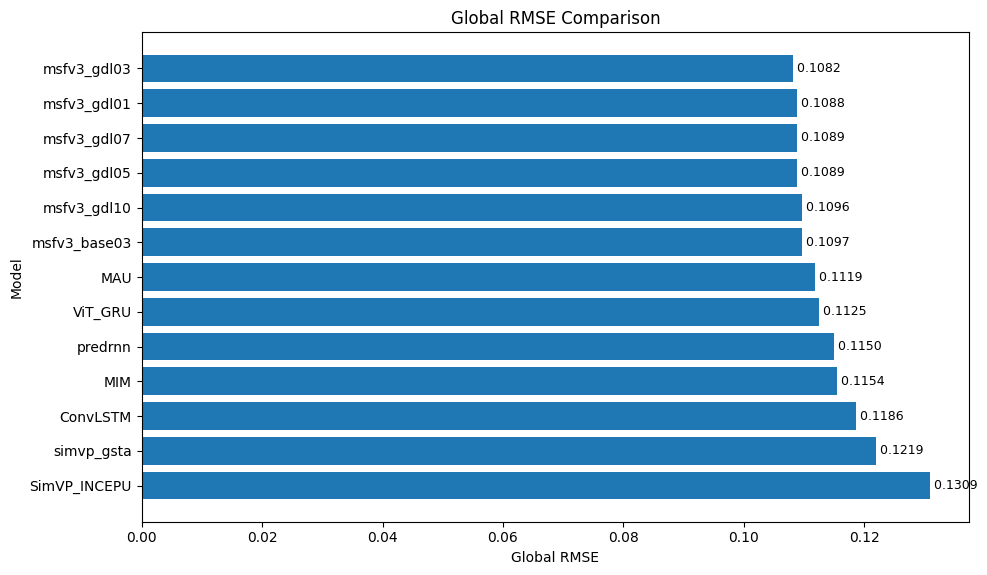

[saved] model_comparison/figs/global_rmse_bar.png


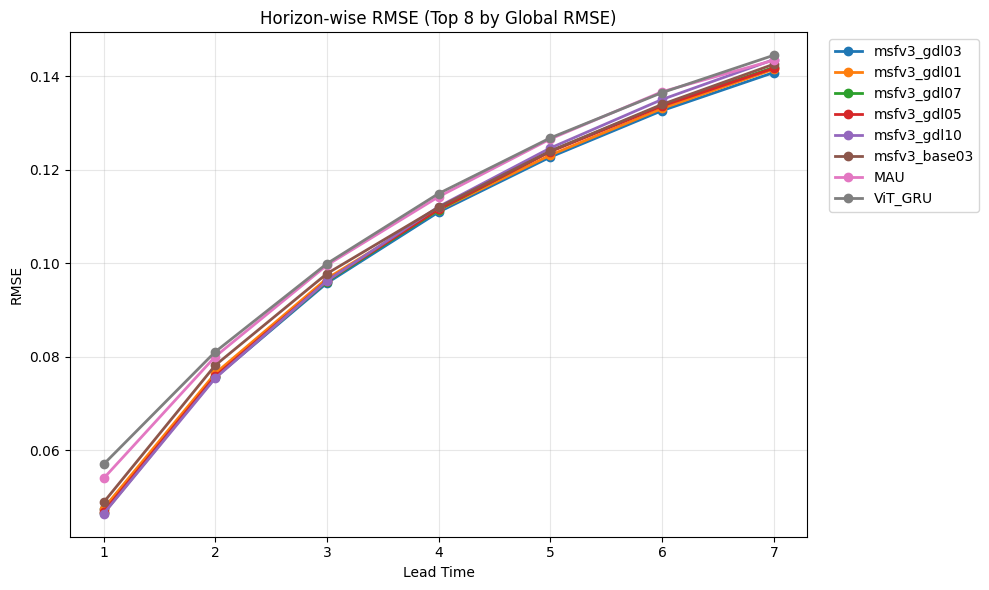

[saved] model_comparison/figs/horizon_rmse_top8_line.png


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

model_names = [
    "ConvLSTM",
    "MAU",
    "MIM",
    "msfv3_base03",
    "msfv3_gdl01",
    "msfv3_gdl03",
    "msfv3_gdl05",
    "msfv3_gdl07",
    "msfv3_gdl10",
    # "msfv3_lk",
    # "msfv3_lk03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU"
]

os.makedirs(FIG_DIR, exist_ok=True)

gt = np.load(GT_PATH)
mask_hw = load_mask(MASK_PATH)

T = gt.shape[1]
lead_days = np.arange(1, T + 1)

rows = []
rmse_t_dict = {}

for name in model_names:
    preds = safe_load_preds(name)
    if preds is None:
        continue

    rmse_global, rmse_t = global_rmse_and_rmse_t(preds, gt, mask_hw)
    rmse_t_dict[name] = rmse_t

    row = {
        "Model": name,
        "Global_RMSE": float(rmse_global)
    }

    for i, v in enumerate(rmse_t, start=1):
        row[f"RMSE_t{i}"] = float(v)

    rows.append(row)

df = pd.DataFrame(rows).sort_values("Global_RMSE").reset_index(drop=True)

metrics = ["Global_RMSE"] + [c for c in df.columns if c.startswith("RMSE_t")]
df_pivot2 = df.set_index("Model")[metrics].T

new_index = ["Global"] + [f"D{i}" for i in range(1, len(df_pivot2.index))]
df_pivot2.index = new_index

df_pivot2_round = df_pivot2.round(6)

def highlight_best_row(s):
    is_min = s == s.min()
    return ['color: #ff3b30; font-weight: bold' if v else '' for v in is_min]

styled_table2 = (
    df_pivot2_round.style
    .apply(highlight_best_row, axis=1)
    .format("{:.6f}")
)

display(styled_table2)

out_csv = os.path.join(FIG_DIR, "global_rmse_and_rmse_t.csv")
df.to_csv(out_csv, index=False)
print(f"[saved] {out_csv}")

out_csv_pivot = os.path.join(FIG_DIR, "global_rmse_and_rmse_t_pivot.csv")
df_pivot2_round.to_csv(out_csv_pivot)
print(f"[saved] {out_csv_pivot}")

horizon_cols = [c for c in df.columns if c.startswith("RMSE_t")]
horizon_cols = sorted(horizon_cols, key=lambda x: int(x.replace("RMSE_t", "")))
lead_days = np.arange(1, len(horizon_cols) + 1)

df_sorted = df.sort_values("Global_RMSE", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(df_sorted))))

y = np.arange(len(df_sorted))
vals = df_sorted["Global_RMSE"].values
models = df_sorted["Model"].values

ax.barh(y, vals)
ax.set_yticks(y)
ax.set_yticklabels(models)
ax.invert_yaxis()
ax.set_xlabel("Global RMSE")
ax.set_ylabel("Model")
ax.set_title("Global RMSE Comparison")

for i, v in enumerate(vals):
    ax.text(v, i, f" {v:.4f}", va="center", fontsize=9)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, "global_rmse_bar.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"[saved] {save_path}")

TOPK_LINE = 8
plot_models = df_sorted["Model"].tolist()[:TOPK_LINE]

fig, ax = plt.subplots(figsize=(10, 6))

for model in plot_models:
    rmse_t = rmse_t_dict[model]
    ax.plot(lead_days, rmse_t, marker="o", linewidth=2, label=model)

ax.set_xticks(lead_days)
ax.set_xlabel("Lead Time")
ax.set_ylabel("RMSE")
ax.set_title(f"Horizon-wise RMSE (Top {TOPK_LINE} by Global RMSE)")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_path = os.path.join(FIG_DIR, f"horizon_rmse_top{TOPK_LINE}_line.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"[saved] {save_path}")

In [9]:
MODEL_NAMES = [
    "ConvLSTM",
    "MAU",
    "MIM",

    # "msfv3_base03",
    # "msfv3_gdl01",
    "msfv3_gdl03",
    # "msfv3_gdl05",
    # "msfv3_gdl10",
    # "msfv3_lk",
    # "msfv3_lk03",

    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU"
]

win: 417 samples
spr: 460 samples
sum: 460 samples
fal: 455 samples


Model,msfv3_gdl03,MAU,ViT_GRU,predrnn,MIM,ConvLSTM,simvp_gsta,SimVP_INCEPU
Season,,,,,,,,
win,0.098076,0.098894,0.102599,0.103351,0.103551,0.105965,0.106015,0.117540
spr,0.126848,0.128015,0.131851,0.131125,0.131647,0.133363,0.133991,0.150828
sum,0.111498,0.123258,0.117283,0.125825,0.126634,0.127983,0.137242,0.141173
fal,0.091970,0.091611,0.093457,0.094449,0.094423,0.102742,0.104960,0.108011
avg4,0.107098,0.110444,0.111298,0.113688,0.114064,0.117513,0.120552,0.129388


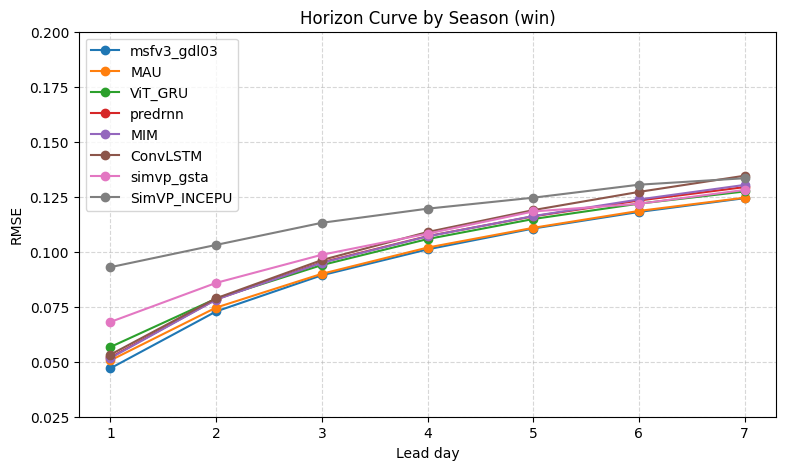

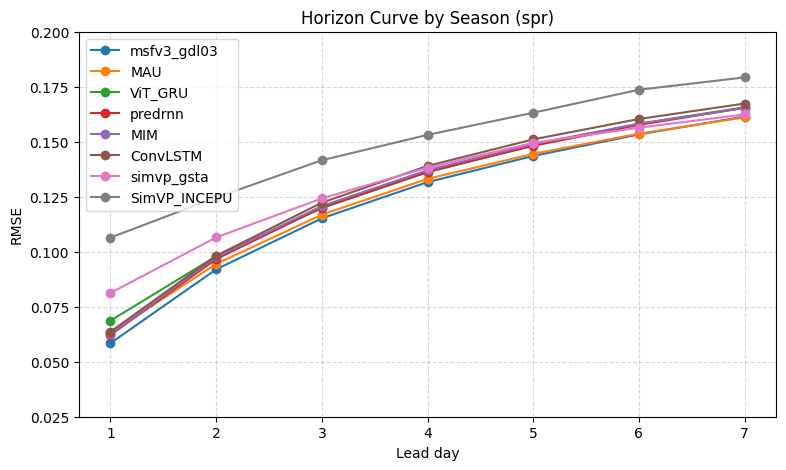

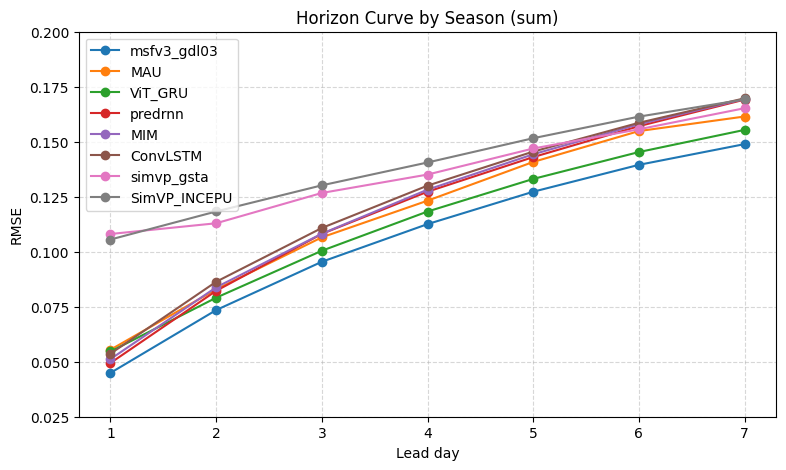

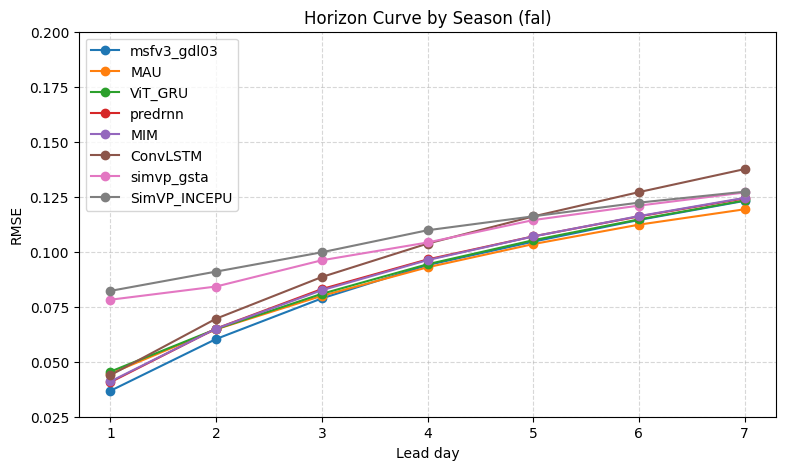

<Figure size 1000x400 with 0 Axes>

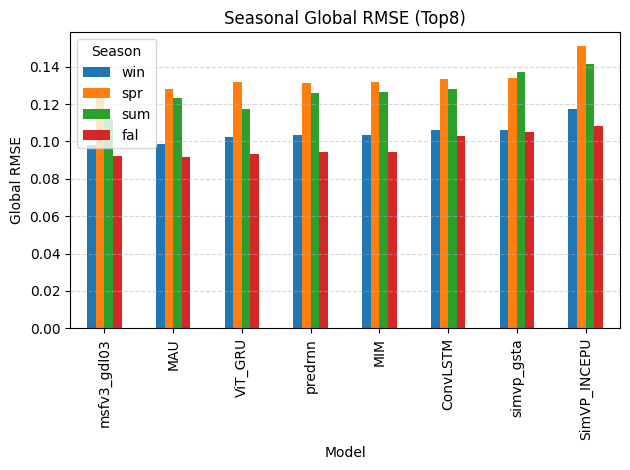

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 저장
SAVE = False
OUT_DIR = os.path.join(PRED_DIR, "seasonal")
os.makedirs(OUT_DIR, exist_ok=True)


VIS_MODELS = model_names

# =========================
# 1) 로드 & 유틸
# =========================
gt = np.load(GT_PATH)  # (N,T,C,H,W)
mask = np.load(MASK_PATH)
mask_hw = (mask > 0) if mask.dtype != np.bool_ else mask

N, T, C, H, W = gt.shape
lead_days = np.arange(1, T + 1)

def safe_load_preds(name):
    path = os.path.join(PRED_DIR, f"{name}_preds.npy")
    if not os.path.exists(path):
        print(f"[skip] missing: {path}")
        return None
    return np.load(path)

def global_rmse_and_rmse_t(preds, gt, mask_hw):
    """
    preds, gt: (N, T, C, H, W)
    mask_hw: (H,W) bool
    """
    m = mask_hw.astype(np.float32)[None, None, None, :, :]  # (1,1,1,H,W)
    diff2 = (preds - gt) ** 2
    diff2 = np.nan_to_num(diff2, nan=0.0)

    # global
    sum_sq = np.sum(diff2 * m)
    count = np.sum(m) * preds.shape[0] * preds.shape[1] * preds.shape[2]
    rmse_global = np.sqrt(sum_sq / count)

    # per lead time
    sum_sq_t = np.sum(diff2 * m, axis=(0, 2, 3, 4))  # (T,)
    count_t = np.sum(mask_hw) * preds.shape[0] * preds.shape[2]
    rmse_t = np.sqrt(sum_sq_t / count_t)

    return float(rmse_global), rmse_t.astype(np.float64)

# =========================
# 2) 시즌 매핑 (spr/sum/fal/win)
# =========================
def month_to_season(m):
    if m in (12, 1, 2):
        return "win"
    if m in (3, 4, 5):
        return "spr"
    if m in (6, 7, 8):
        return "sum"
    return "fal"

def build_season_indices(all_meta_months):
    months = np.asarray(all_meta_months).astype(int)
    season_idx = {"win": [], "spr": [], "sum": [], "fal": []}
    for i, m in enumerate(months):
        season_idx[month_to_season(m)].append(i)
    return {k: np.asarray(v, dtype=int) for k, v in season_idx.items()}

assert "all_meta_months" in globals(), "all_meta_months 변수가 필요합니다. (길이 N의 월 정보 배열)"
assert len(all_meta_months) == N, f"all_meta_months 길이({len(all_meta_months)}) != gt 샘플 수({N})"

season_indices = build_season_indices(all_meta_months)
for s, idx in season_indices.items():
    print(f"{s}: {len(idx)} samples")

# =========================
# 3) 시즌별 Global RMSE + RMSE_t 계산
# =========================
rows_global = []
rows_t = []

for name in MODEL_NAMES:
    preds = safe_load_preds(name)
    if preds is None:
        continue

    for season, idx in season_indices.items():
        if idx.size == 0:
            continue
        p_s = preds[idx]
        y_s = gt[idx]

        rmse_g, rmse_t = global_rmse_and_rmse_t(p_s, y_s, mask_hw)

        rows_global.append({
            "Model": name,
            "Season": season,
            "Global_RMSE": rmse_g,
            "N": int(idx.size),
        })

        for t_i in range(T):
            rows_t.append({
                "Model": name,
                "Season": season,
                "LeadDay": int(t_i + 1),
                "RMSE": float(rmse_t[t_i]),
            })

df_global = pd.DataFrame(rows_global)
df_t = pd.DataFrame(rows_t)




pivot_global = df_global.pivot(index="Model", columns="Season", values="Global_RMSE")
pivot_global = pivot_global[["win", "spr", "sum", "fal"]]
pivot_global["avg4"] = pivot_global.mean(axis=1)

# TopK
pivot_global_sorted = pivot_global.sort_values("avg4")
TOPK = min(20, len(pivot_global_sorted))
top_models = pivot_global_sorted.index.tolist()[:TOPK]

#  월별표처럼: (행=Season, 열=Model)로 바꾸기
tbl = pivot_global_sorted.loc[top_models, ["win", "spr", "sum", "fal", "avg4"]].T
tbl_round = tbl.round(6)

BEST_COLOR = "#ff3b30" 

def highlight_best_row(s):
    is_min = s == s.min()
    out = []
    for v in is_min:
        if v:
            out.append(f' color: {BEST_COLOR}; font-weight: bold')
        else:
            out.append('')
    return out

styled_tbl = (
    tbl_round.style
    .apply(highlight_best_row, axis=1)  #  행(시즌/avg)별 best 모델 강조
    .format("{:.6f}")
)

display(styled_tbl)

# (선택) CSV 저장은 기존대로
if SAVE:
    out_csv = os.path.join(OUT_DIR, "seasonal_global_rmse.csv")
    pivot_global_sorted.to_csv(out_csv)
    print(f"[saved] {out_csv}")
# =========================
#  4.5) 공통 y축(범위+눈금) 만들기: "모든 시즌 horizon plot이 동일"하게
# =========================
def nice_step(x):
    """틱 간격을 보기 좋은 값(1/2/2.5/5*10^k)으로"""
    if x <= 0:
        return 0.01
    exp = np.floor(np.log10(x))
    f = x / (10 ** exp)
    if f <= 1:
        nf = 1
    elif f <= 2:
        nf = 2
    elif f <= 2.5:
        nf = 2.5
    elif f <= 5:
        nf = 5
    else:
        nf = 10
    return nf * (10 ** exp)

def yaxis_plain(ax):
    fmt = mticker.ScalarFormatter(useOffset=False)
    fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt)
    ax.yaxis.get_offset_text().set_visible(False)

# TopK 기준으로 공통 범위 계산 (전체 모델 기준으로 하고 싶으면 .isin(top_models) 부분 제거)
sub_all = df_t[df_t["Model"].isin(top_models)]
ymin = float(sub_all["RMSE"].min())
ymax = float(sub_all["RMSE"].max())
pad = (ymax - ymin) * 0.07 if ymax > ymin else 0.01

y0 = ymin - pad
y1 = ymax + pad

# 원하는 눈금 개수(대략) -> 간격 계산
target_ticks = 8  # 7~9 정도로 조절
raw_step = (y1 - y0) / (target_ticks - 1)
step = nice_step(raw_step)

# 범위를 step의 배수로 깔끔하게 맞춤
y0 = np.floor(y0 / step) * step
y1 = np.ceil(y1 / step) * step
yticks = np.arange(y0, y1 + step * 0.5, step)

# =========================
# 5) 시즌별 Horizon Curve (TopK) +  동일 y축 적용
# =========================
for season in ["win", "spr", "sum", "fal"]:
    plt.figure(figsize=(9, 5))
    sub = df_t[(df_t["Season"] == season) & (df_t["Model"].isin(top_models))]

    for name in top_models:
        s2 = sub[sub["Model"] == name].sort_values("LeadDay")
        if len(s2) == 0:
            continue
        plt.plot(s2["LeadDay"], s2["RMSE"], marker="o", label=name)

    plt.title(f"Horizon Curve by Season ({season})")
    plt.xlabel("Lead day")
    plt.ylabel("RMSE")
    plt.xticks(lead_days)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left")

    ax = plt.gca()
    ax.set_ylim(y0, y1)          #  모든 시즌 동일 범위
    ax.set_yticks(yticks)        #  모든 시즌 동일 눈금
    yaxis_plain(ax)             

    if SAVE:
        fig_path = os.path.join(OUT_DIR, f"horizon_curve_{season}_top{TOPK}.png")
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        print(f"[saved] {fig_path}")

    plt.show()

# =========================
# 6) (기존) 시즌별 Global RMSE 막대그래프
# =========================
plt.figure(figsize=(10, 4))
bars = pivot_global.loc[top_models, ["win", "spr", "sum", "fal"]]
ax = bars.plot(kind="bar")
plt.title(f"Seasonal Global RMSE (Top{TOPK})")
plt.xlabel("Model")
plt.ylabel("Global RMSE")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
yaxis_plain(ax)

if SAVE:
    fig_path = os.path.join(OUT_DIR, f"seasonal_global_rmse_top{TOPK}.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"[saved] {fig_path}")

plt.show()

In [11]:

# 역정규화 파라미터
MEAN_SST = 22.5081844329834
STD_SST  = 4.8933515548706055

def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean

def plot_sample_multi(sample_idx, model_names):
    """
    sample_idx: int
    model_names: list[str]  # 비교할 모델 이름들
    """
    # 1) 예측 로드 + 역정규화
    preds_dict = {}
    for m in model_names:
        p = safe_load_preds(m)
        if p is None:
            print(f"[skip] {m} 로드 실패")
            return
        preds_dict[m] = denorm_sst(p)

    # 2) GT 샘플 추출 + 역정규화
    y = denorm_sst(gt[sample_idx])  # (T,1,H,W)
    pred_samples = {m: preds_dict[m][sample_idx] for m in model_names}  # 각 (T,1,H,W)

    # 3) mask 적용
    y_vis = apply_mask_nan(y, mask_hw)
    pred_vis = {m: apply_mask_nan(pred_samples[m], mask_hw) for m in model_names}

    # 4) 색 범위 (GT 기준, 역정규화된 °C 기준)
    vmin, vmax = infer_vmin_vmax(y, mask_hw, percentile=(10, 98))

    # 5) subplot 크기 설정
    n_models = len(model_names)
    nrows = 1 + n_models   # GT 1행 + 모델 N행
    ncols = T

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(2.2 * ncols, 2.2 * nrows),
        constrained_layout=True
    )

    # axes shape 보정 (혹시 T=1인 경우 대비)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    # 6) 첫 행: GT
    for t in range(T):
        im0 = axes[0, t].imshow(
            y_vis[t, 0],
            vmin=vmin,
            vmax=vmax,
            cmap=CMAP_MAIN,
            origin="lower"
        )
        axes[0, t].set_title(f"GT D{t+1}")
        axes[0, t].axis("off")

    # 7) 아래 행들: 각 모델
    for r, m in enumerate(model_names, start=1):
        for t in range(T):
            axes[r, t].imshow(
                pred_vis[m][t, 0],
                vmin=vmin,
                vmax=vmax,
                cmap=CMAP_MAIN,
                origin="lower"
            )
            axes[r, t].set_title(f"{m} D{t+1}")
            axes[r, t].axis("off")

    # 8) colorbar / 제목
    cbar = fig.colorbar(im0, ax=axes, shrink=0.6, location="right")
    cbar.set_label("SST (°C)")

    fig.suptitle(
        f"Sample {sample_idx} - GT vs {len(model_names)} Models (Lead 1~{T} days, denormalized)",
        y=1.02
    )

    plt.show()

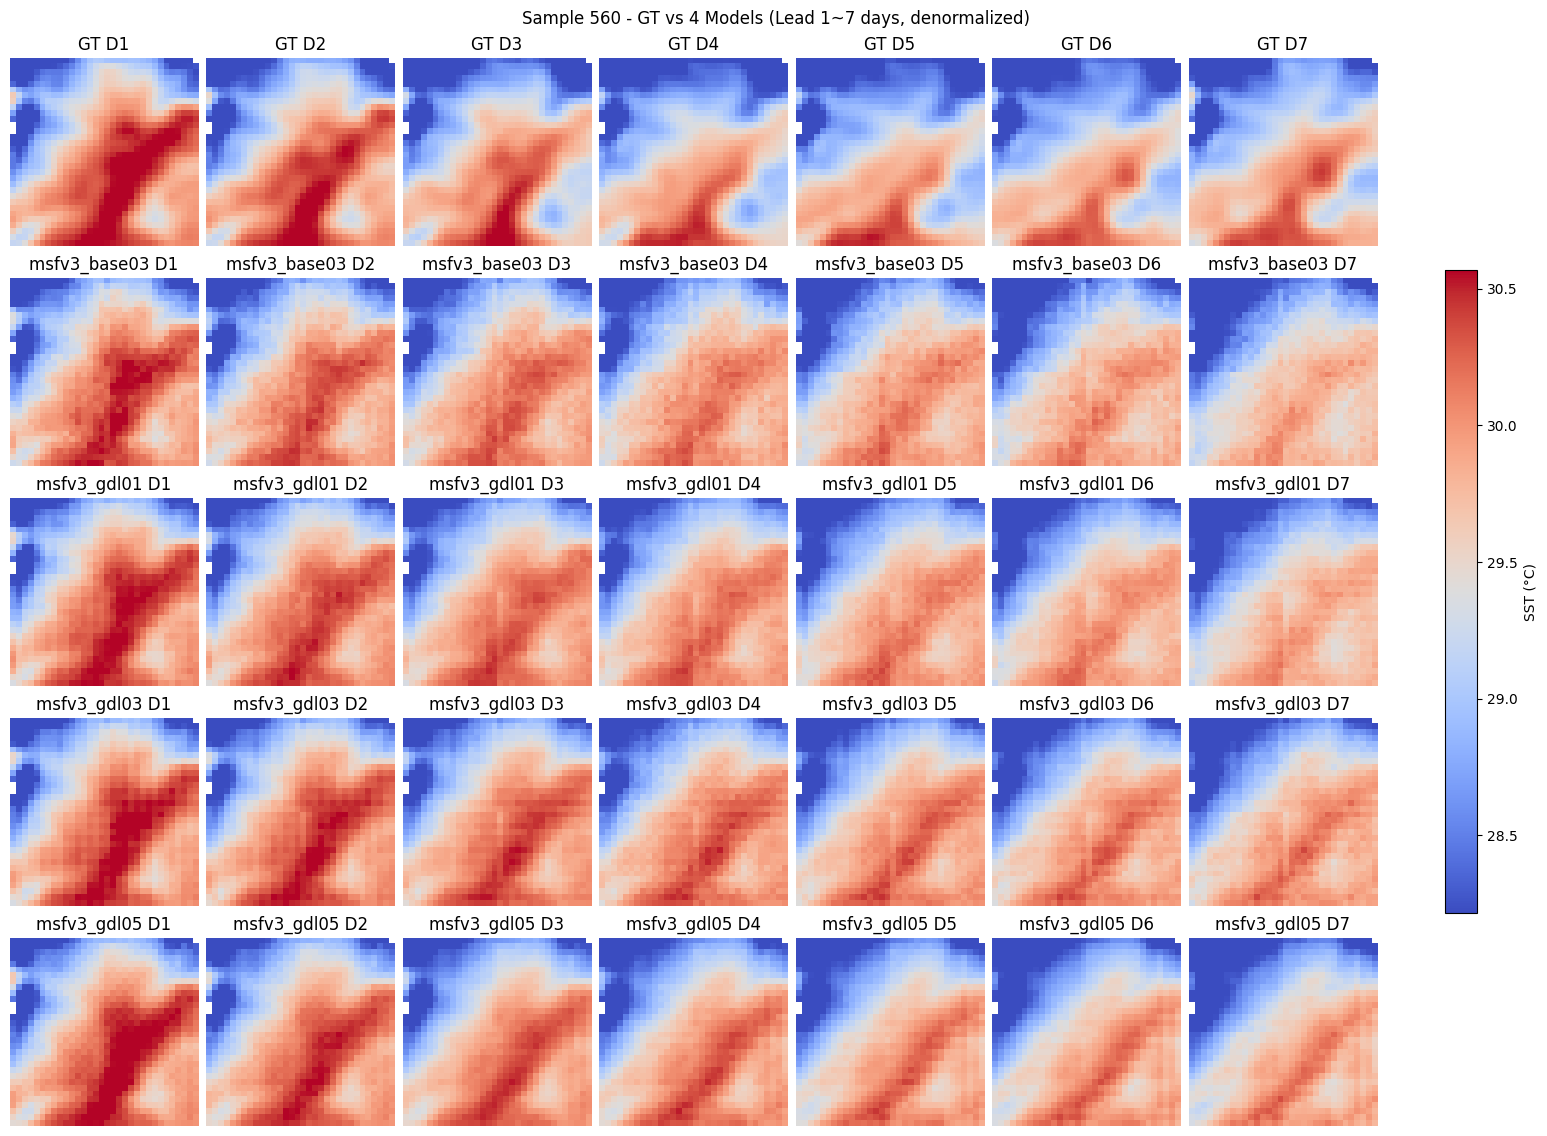

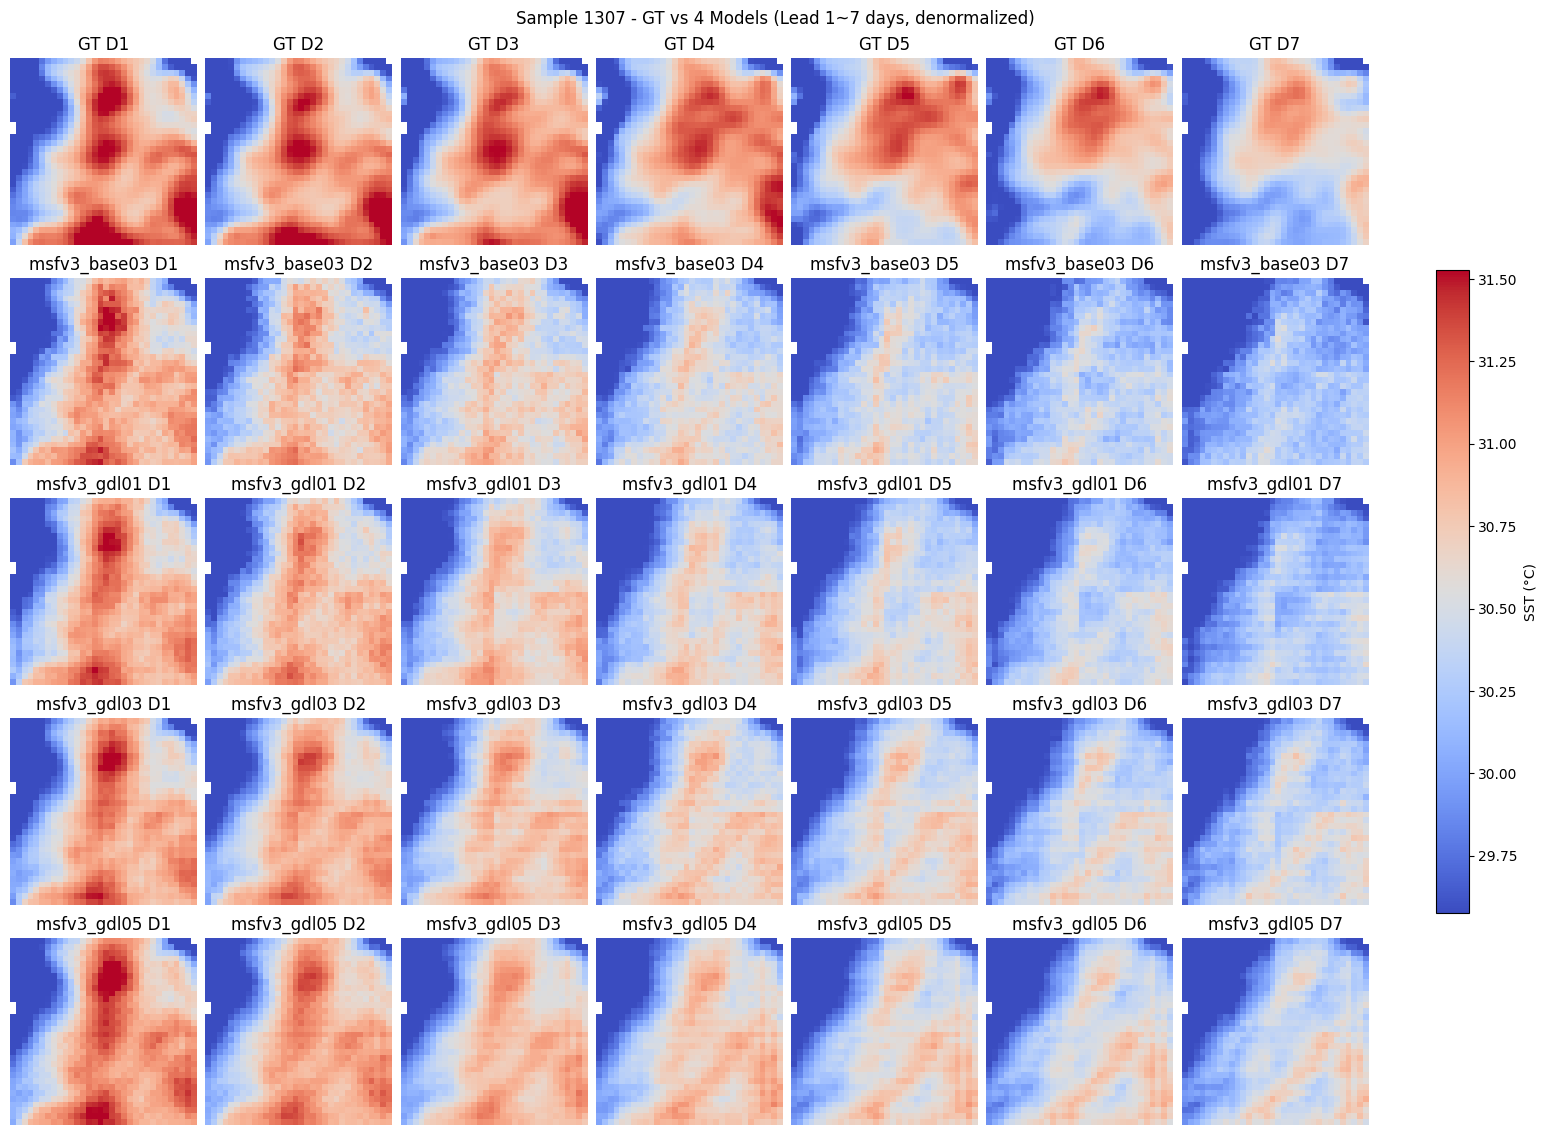

In [12]:
model_names = [

    "msfv3_base03",
    "msfv3_gdl01",
    "msfv3_gdl03",
    "msfv3_gdl05",
]

CMAP_MAIN = "coolwarm"

# SAMPLE_IDXS = [120, 560, 310]
SAMPLE_IDXS = [560,1307]


for sidx in SAMPLE_IDXS:
    plot_sample_multi(sidx, model_names)

[saved] ./Analysis_gdl_560.png


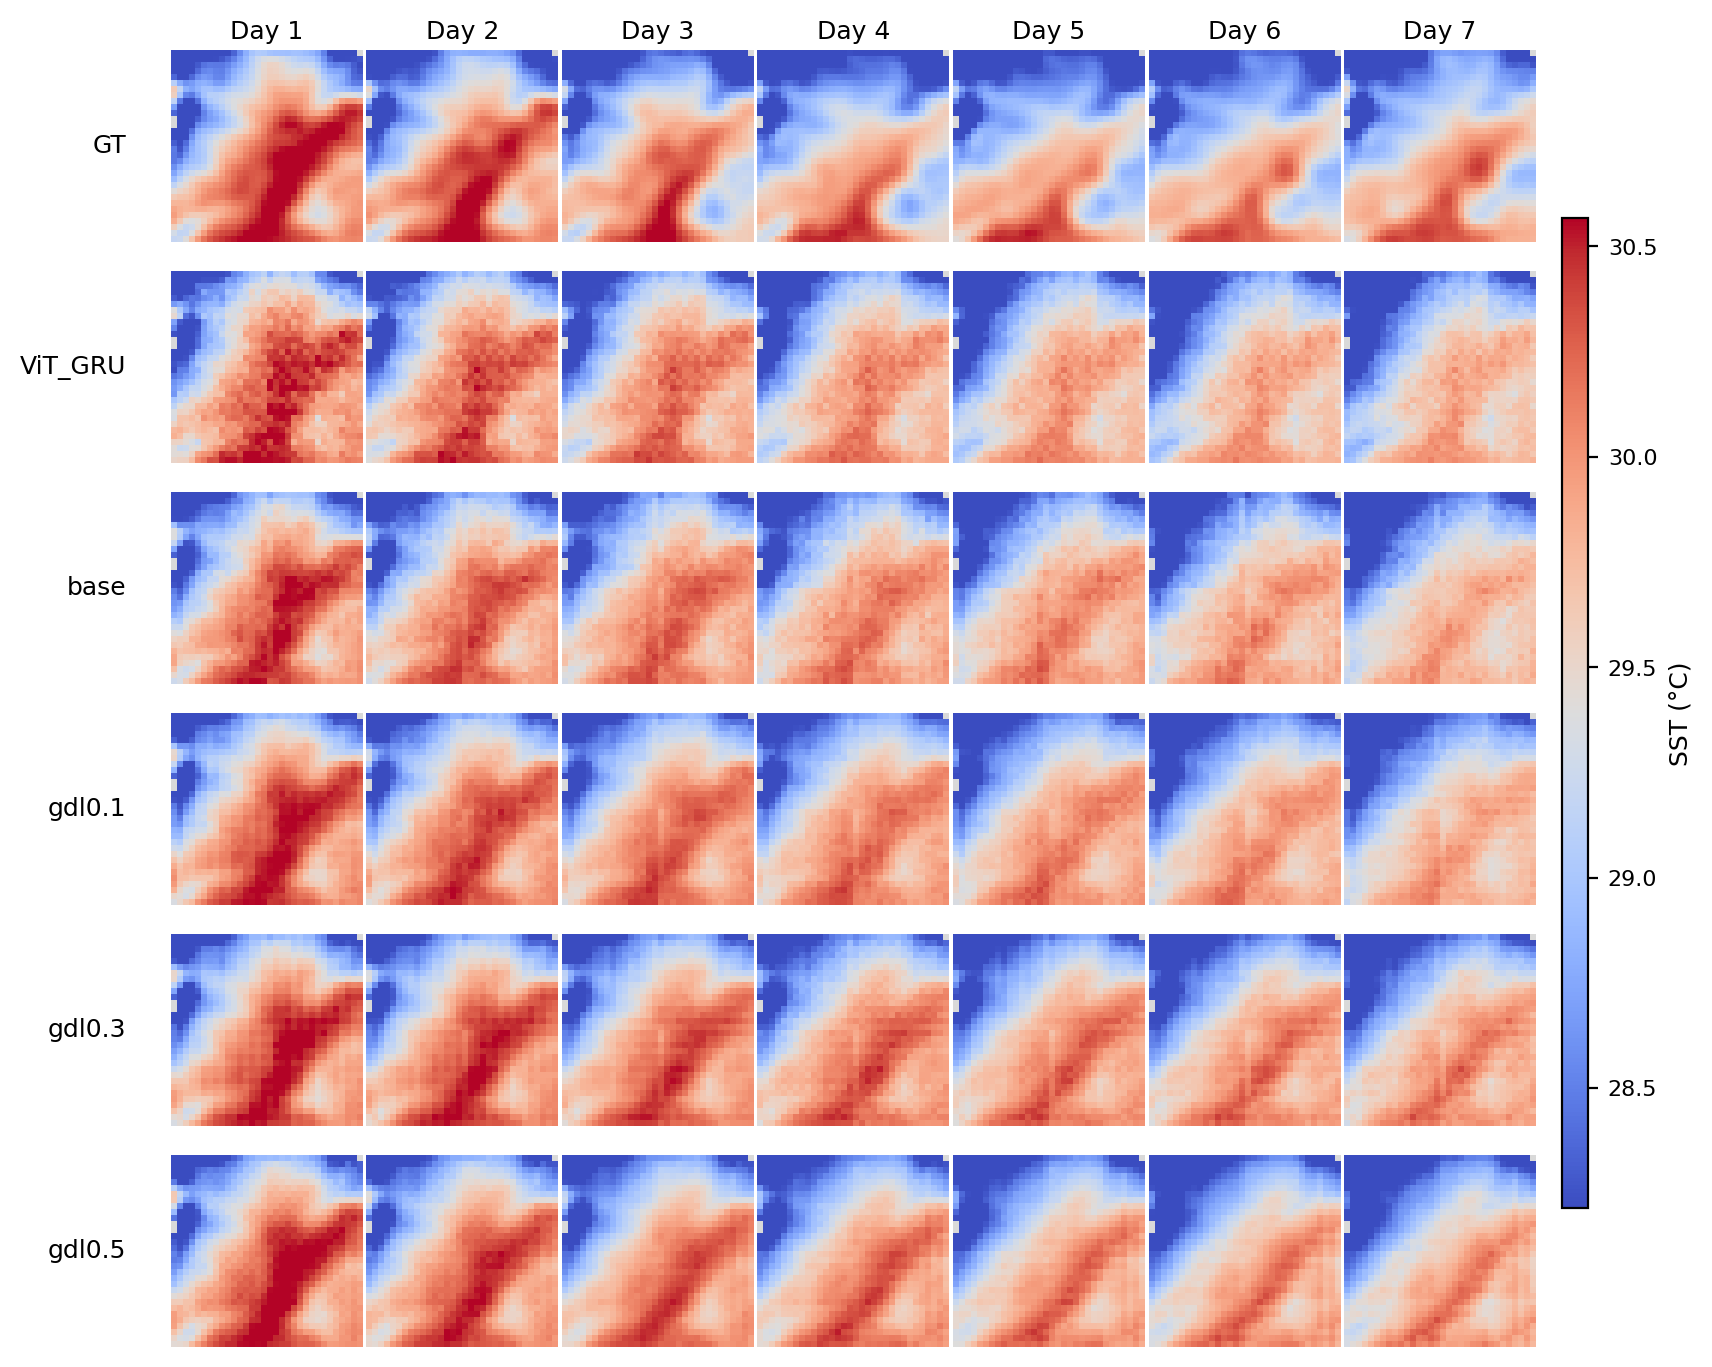

[saved] ./Analysis_gdl_1307.png


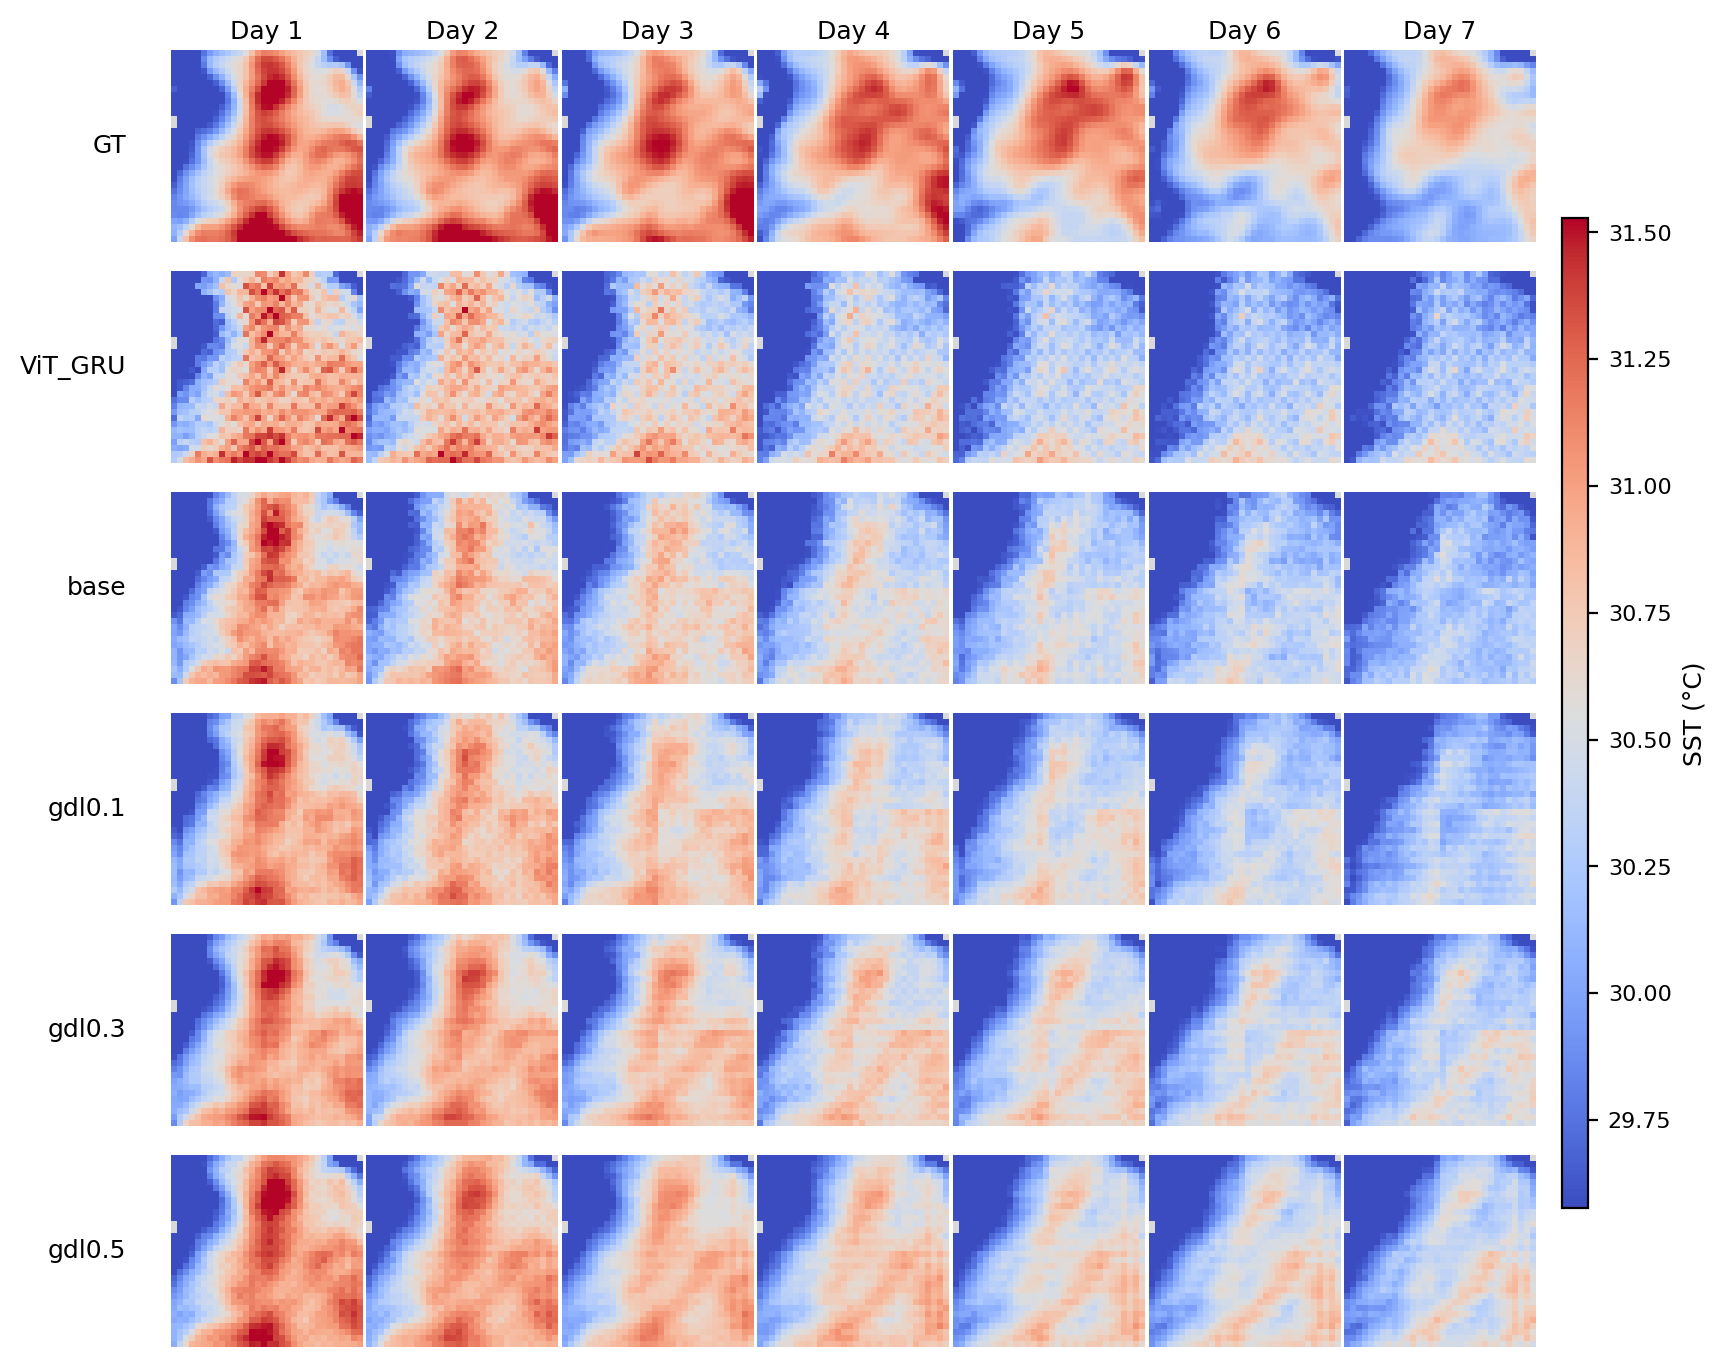

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 설정
# =========================================================
MEAN_SST = 22.5081844329834
STD_SST  = 4.8933515548706055

CMAP_MAIN = "coolwarm"
MASK_COLOR = "#D9D9D9"   # 마스크 회색

model_names = [
    "ViT_GRU",
    "msfv3_base03",
    "msfv3_gdl01",
    "msfv3_gdl03",
    "msfv3_gdl05",
]

MODEL_LABELS = {
    "msfv3_base03": "base",
    "msfv3_gdl01": "gdl0.1",
    "msfv3_gdl03": "gdl0.3",
    "msfv3_gdl05": "gdl0.5",
}

SAMPLE_IDXS = [560, 1307]

# 패널 크기 조절
PANEL_W = 1.25
PANEL_H = 1.25

# 저장 설정
SAVE_FIG = True
SAVE_DIR = "./"
SAVE_PREFIX = "Analysis_gdl"


def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def make_masked_array(x, mask_hw):
    mask4d = np.broadcast_to(~mask_hw[None, None, :, :], x.shape)
    return np.ma.array(x, mask=mask4d)


def plot_sample_multi(sample_idx, model_names, model_labels=None, save_fig=False, save_dir=None, save_prefix="sample"):
    if model_labels is None:
        model_labels = {}

    # 1) GT 샘플 추출 + 역정규화 (1번만)
    y = denorm_sst(gt[sample_idx])   # (T, 1, H, W)
    T_local = y.shape[0]

    # 2) 예측 로드 + 역정규화 (1번만)
    pred_samples = {}
    for m in model_names:
        p = safe_load_preds(m)
        if p is None:
            print(f"[skip] {m} 로드 실패")
            return
        pred_samples[m] = denorm_sst(p[sample_idx])   # (T, 1, H, W)

    # 3) mask 적용
    y_vis = make_masked_array(y, mask_hw)
    pred_vis = {
        m: make_masked_array(pred_samples[m], mask_hw)
        for m in model_names
    }

    # 4) 색 범위: GT 기준
    valid_gt = y[:, 0][:, mask_hw]
    valid_gt = valid_gt[np.isfinite(valid_gt)]

    if valid_gt.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin = np.percentile(valid_gt, 10)
        vmax = np.percentile(valid_gt, 98)
        if vmin >= vmax:
            vmin = np.min(valid_gt)
            vmax = np.max(valid_gt)

    # 5) 행/열 구성
    row_names = ["GT"] + [model_labels.get(m, m) for m in model_names]
    row_arrays = [y_vis] + [pred_vis[m] for m in model_names]

    nrows = len(row_arrays)
    ncols = T_local

    # 6) colormap 설정
    cmap_obj = plt.get_cmap(CMAP_MAIN).copy()
    cmap_obj.set_bad(color=MASK_COLOR)

    # 7) figure / axes
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(PANEL_W * ncols, PANEL_H * nrows),
        dpi=200
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    COL_TITLE_FS = 8
    ROW_LABEL_FS = 8
    CBAR_LABEL_FS = 8
    CBAR_TICK_FS = 7

    fig.subplots_adjust(
        left=0.12,
        right=0.90,
        top=0.95,
        bottom=0.07,
        wspace=0.02,
        hspace=0.03
    )

    # 8) 그리기
    im = None
    for r in range(nrows):
        for c in range(ncols):
            im = axes[r, c].imshow(
                row_arrays[r][c, 0],
                vmin=vmin,
                vmax=vmax,
                cmap=cmap_obj,
                origin="lower",
                interpolation="nearest"
            )

            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])

            for spine in axes[r, c].spines.values():
                spine.set_visible(False)

            if r == 0:
                axes[r, c].set_title(f"Day {c + 1}", fontsize=COL_TITLE_FS, pad=4)

            if c == 0:
                axes[r, c].set_ylabel(
                    row_names[r],
                    fontsize=ROW_LABEL_FS,
                    rotation=0,
                    labelpad=16,
                    va="center",
                    ha="right"
                )

    # 9) 오른쪽 colorbar
    cax = fig.add_axes([0.915, 0.17, 0.015, 0.66])
    cbar = fig.colorbar(im, cax=cax, orientation="vertical")
    cbar.set_label("SST (°C)", fontsize=CBAR_LABEL_FS)
    cbar.ax.tick_params(labelsize=CBAR_TICK_FS)

    # 10) 저장
    if save_fig:
        if save_dir is None:
            save_dir = "."
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{save_prefix}_{sample_idx}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[saved] {save_path}")

    plt.show()
    plt.close(fig)


for sidx in SAMPLE_IDXS:
    plot_sample_multi(
        sample_idx=sidx,
        model_names=model_names,
        model_labels=MODEL_LABELS,
        save_fig=SAVE_FIG,
        save_dir=SAVE_DIR,
        save_prefix=SAVE_PREFIX,
    )

In [14]:
# model_names = [

#     "msfv3_gdl03",
#     "ViT_GRU",
#     "MIM",
#     "predrnn"
    
# ]

# # SAMPLE_IDXS = [200, 560, 920]
# SAMPLE_IDXS = [150,230,270,280,320,340,360,450,500, 560, 920]


# for sidx in SAMPLE_IDXS:
#     plot_sample_multi(sidx, model_names)

Selected samples: [1165, 1164]


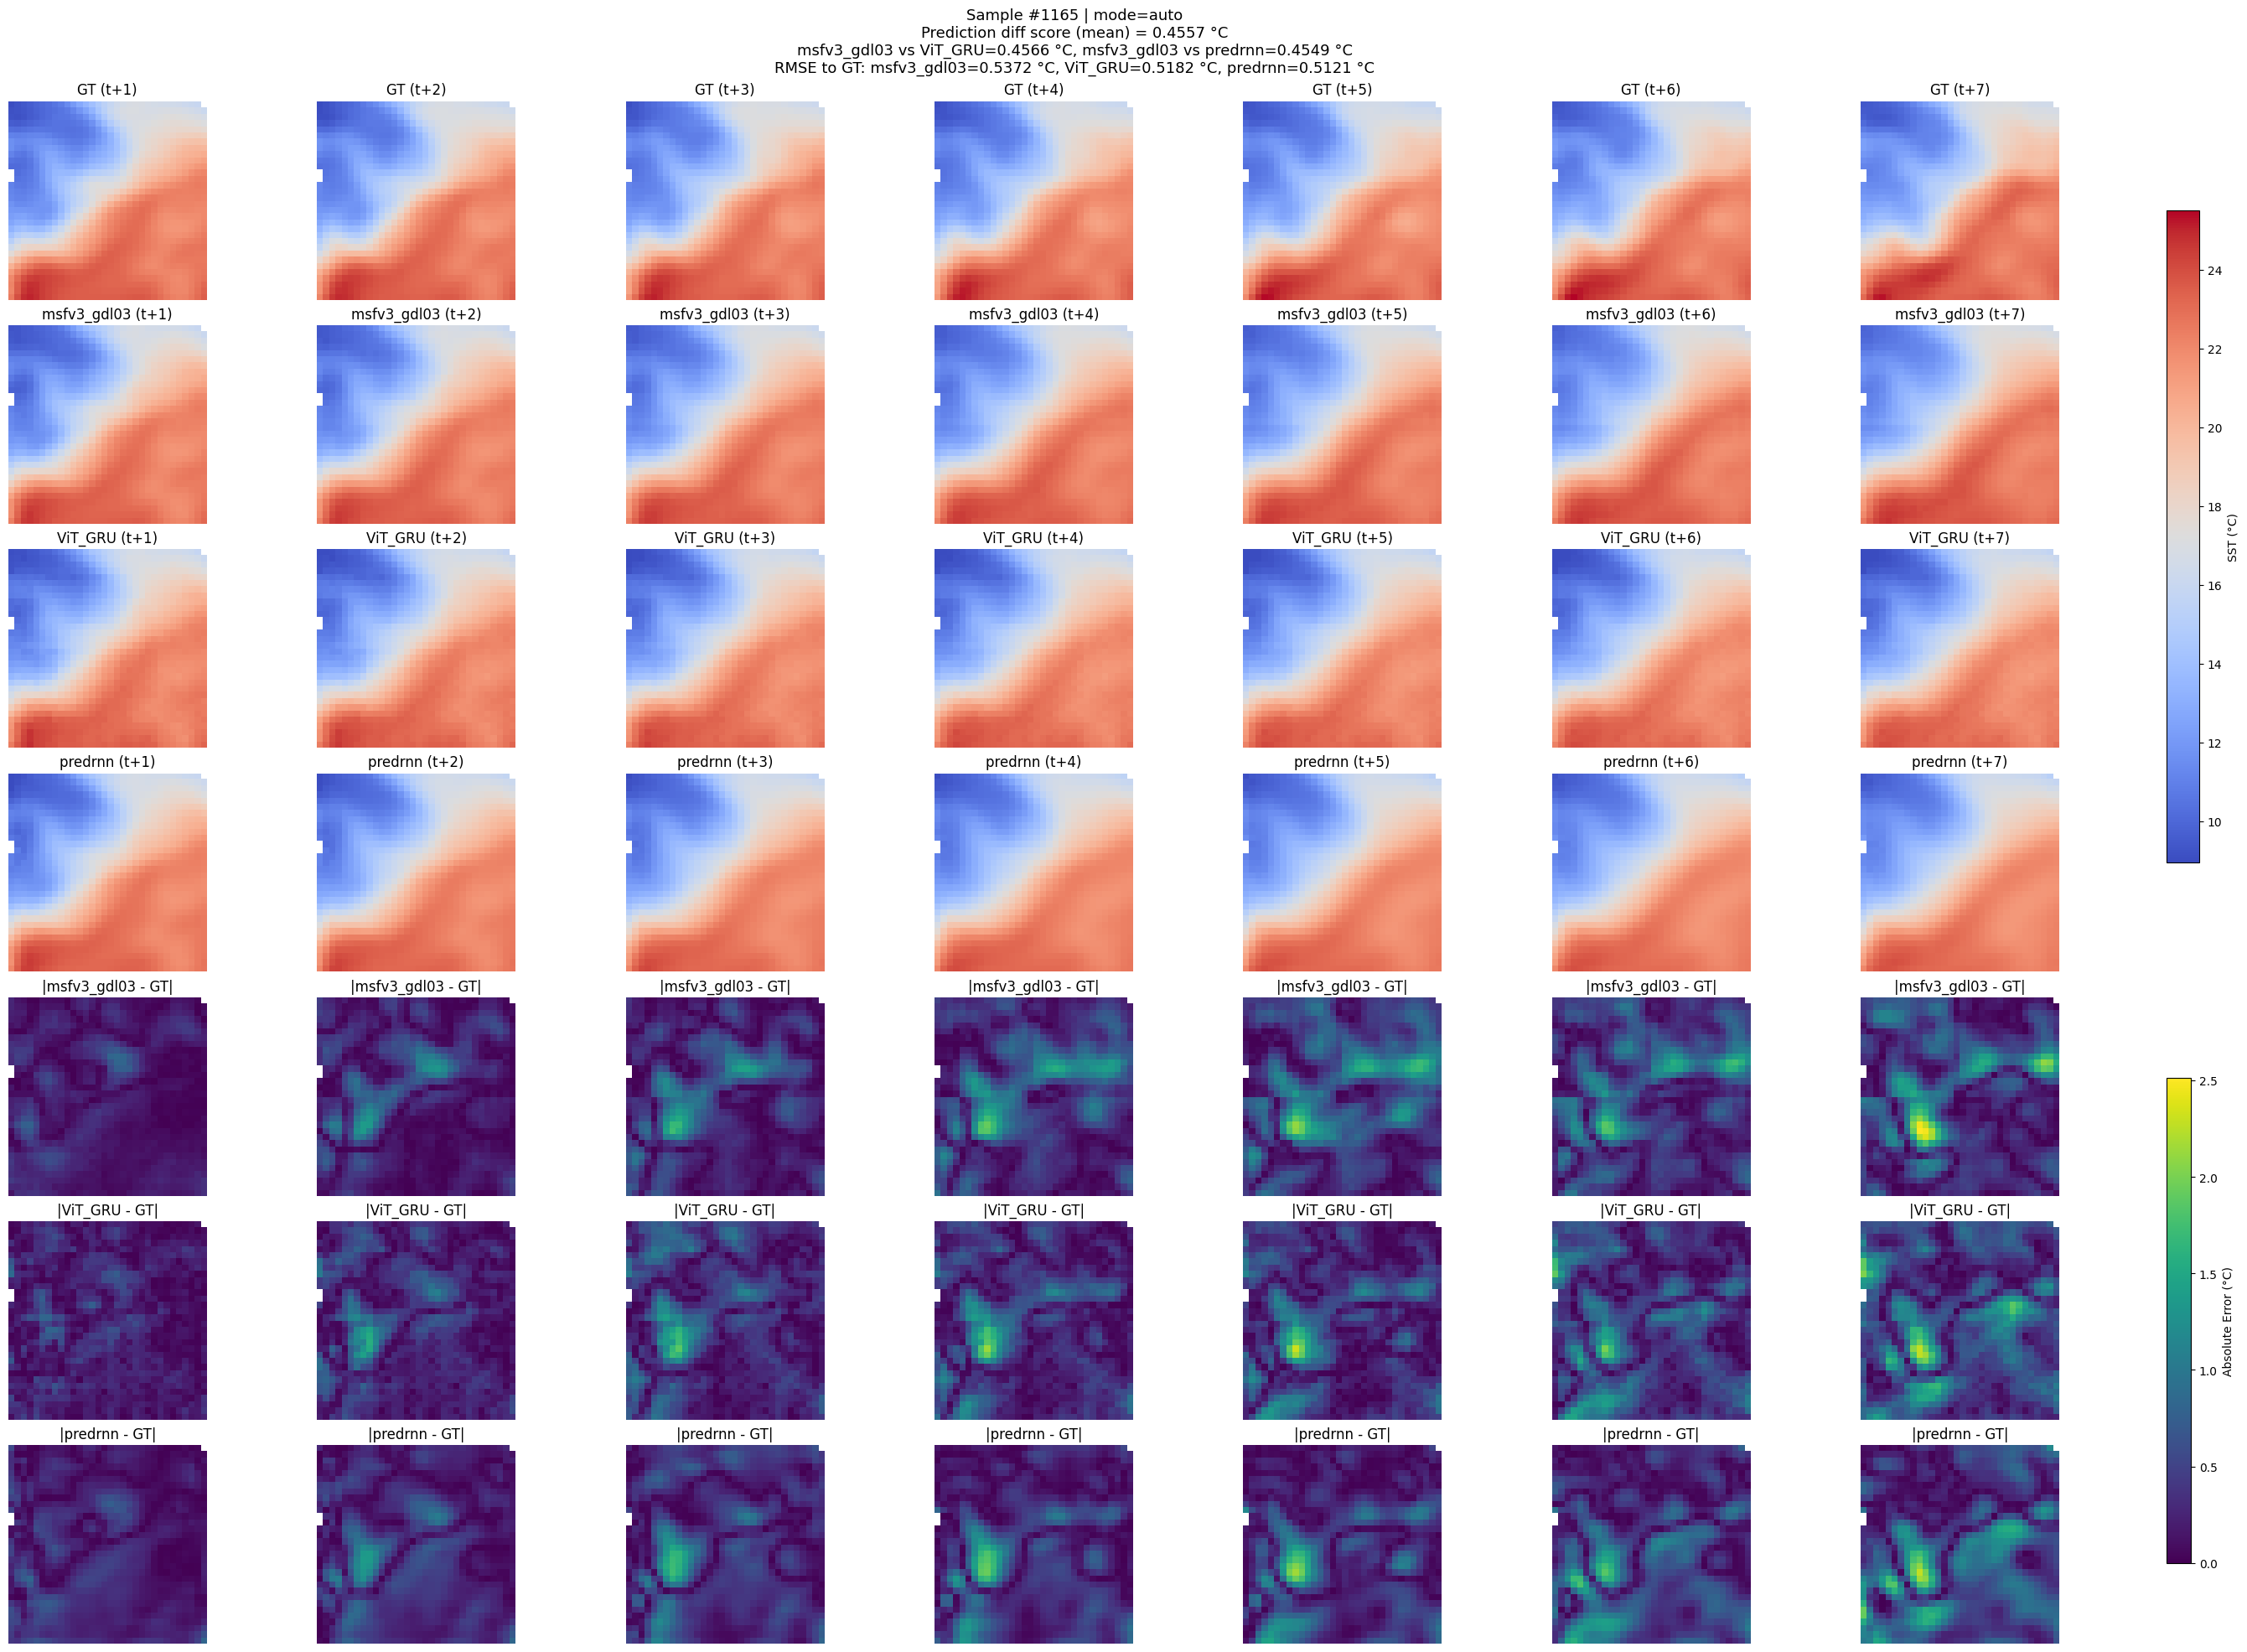

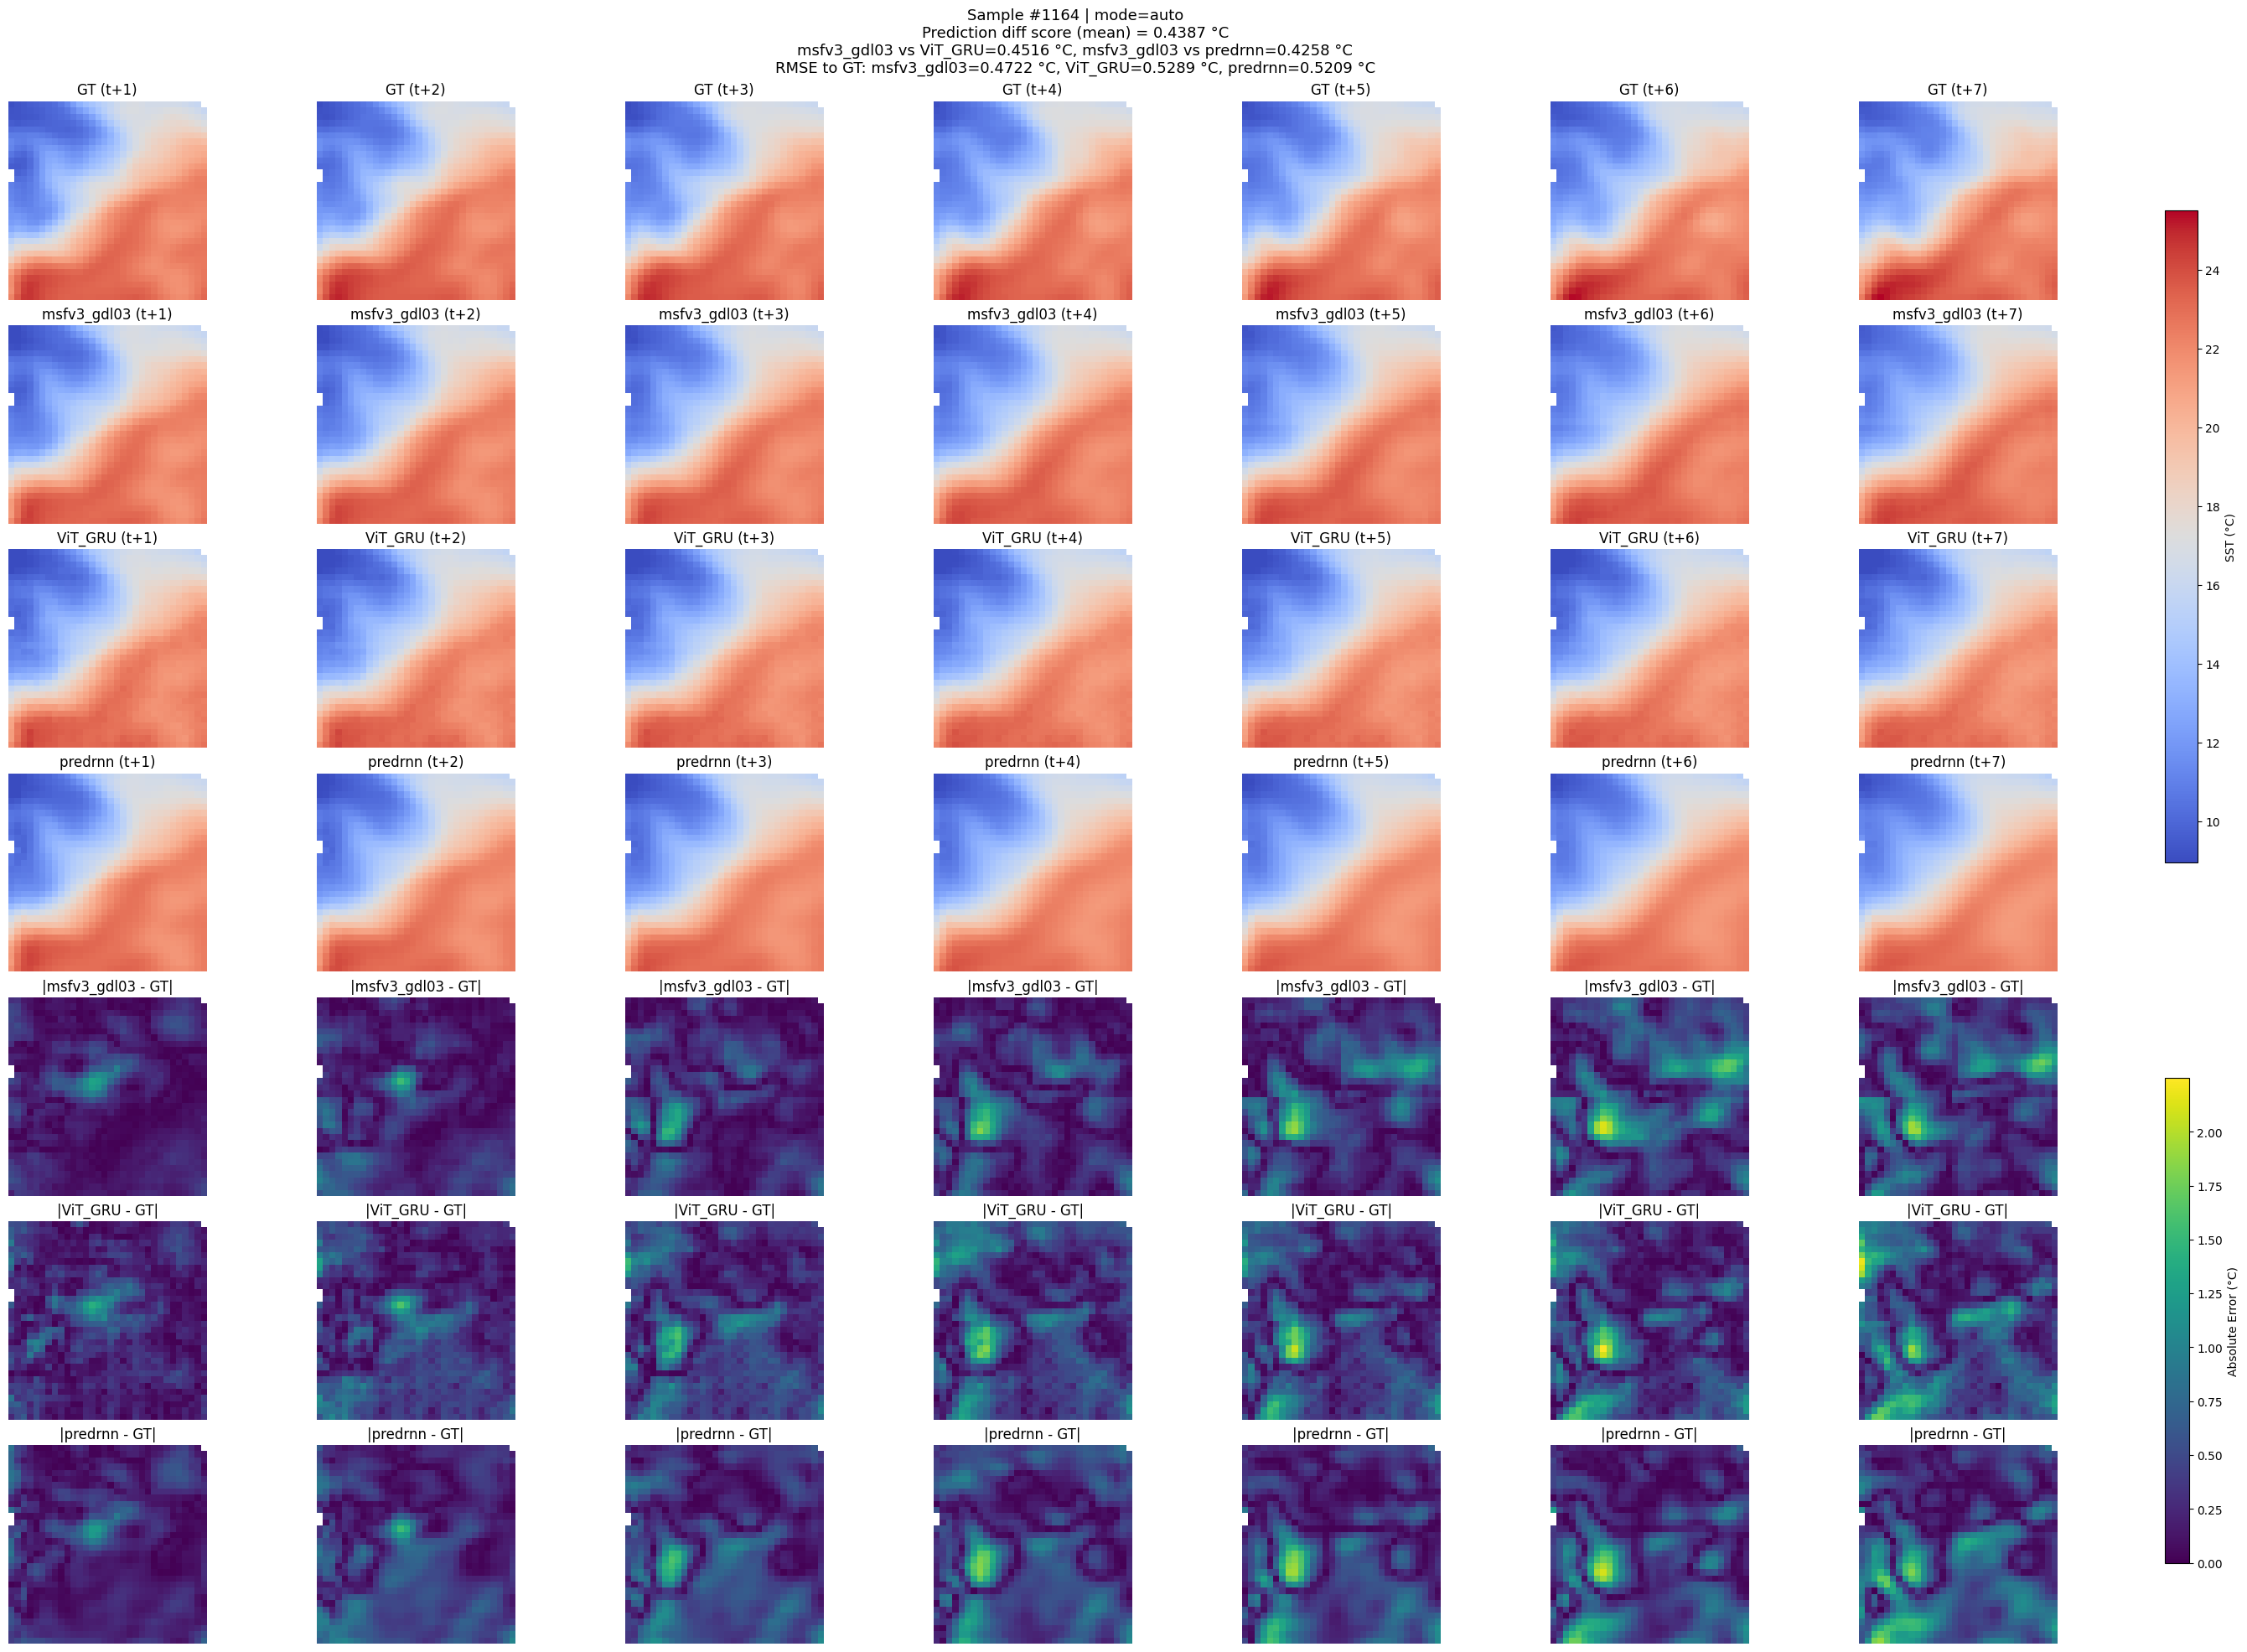

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0) 설정
# =========================================================
PRED_DIR = "model_comparison"
GT_PATH = os.path.join(PRED_DIR, "ground_truth.npy")
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"

# 역정규화 파라미터
MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

# 비교할 모델들 (최대 3개)
MODEL_NAMES = [
    "msfv3_gdl03",
    "ViT_GRU",
    "predrnn"
]
assert 2 <= len(MODEL_NAMES) <= 3, "MODEL_NAMES는 2~3개만 넣어주세요."

# ---------------------------------------------------------
# 샘플 선택 방식
#   SAMPLE_MODE = "auto"   -> 기존처럼 모델 간 차이가 큰 샘플 자동 선택
#   SAMPLE_MODE = "manual" -> 내가 직접 sample index 지정
# ---------------------------------------------------------
SAMPLE_MODE = "auto"   # "auto" or "manual"

# [manual 모드] 직접 보고 싶은 샘플 번호들
MANUAL_SAMPLE_IDXS = [68]

# [auto 모드] 첫 번째 모델과 나머지 모델들의 prediction 차이가 큰 샘플
TOPK = 2
DIFF_AGG = "mean"   # "mean" or "max"
LEADS_TO_EVAL = None  # None이면 전체 horizon 사용

# 그림에 표시할 horizon
LEADS_TO_SHOW = [0,1, 2,3, 4,5, 6] 

# 저장 옵션
SAVE_FIG = False
OUT_DIR = os.path.join(PRED_DIR, "qualitative_compare_only_denorm")
os.makedirs(OUT_DIR, exist_ok=True)


# =========================================================
# 1) 유틸 함수
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def normalize_spatial_mask(mask, H, W):
    """
    mask를 최종적으로 (H, W) bool 형태로 맞춤
    """
    mask = np.asarray(mask)
    mask = np.squeeze(mask)

    if mask.shape == (H, W):
        return mask.astype(bool)

    if mask.ndim >= 2 and mask.shape[-2:] == (H, W):
        while mask.ndim > 2:
            mask = mask[0]
        return mask.astype(bool)

    raise ValueError(f"Mask shape mismatch: got {mask.shape}, expected (*, {H}, {W})")


def samplewise_masked_rmse(a, b, mask, leads=None, eps=1e-8):
    """
    a, b: (N, T, C, H, W)
    mask: (H, W) bool
    return: (N,)
    """
    if leads is not None:
        a = a[:, leads]
        b = b[:, leads]

    m = mask[None, None, None, :, :]
    diff2 = (a - b) ** 2

    num = np.sum(diff2 * m, axis=(1, 2, 3, 4))
    den = mask.sum() * a.shape[1] * a.shape[2]

    return np.sqrt(num / np.clip(den, eps, None))


def apply_mask2d(x2d, mask, fill=np.nan):
    out = x2d.copy()
    out[~mask] = fill
    return out


def masked_minmax(arr, mask):
    """
    arr: (..., H, W)
    mask: (H, W)
    """
    vals = arr[..., mask]
    return np.nanmin(vals), np.nanmax(vals)


def validate_manual_sample_idxs(sample_idxs, N):
    sample_idxs = list(sample_idxs)
    if len(sample_idxs) == 0:
        raise ValueError("MANUAL_SAMPLE_IDXS가 비어 있습니다.")

    bad = [i for i in sample_idxs if (not isinstance(i, (int, np.integer))) or i < 0 or i >= N]
    if len(bad) > 0:
        raise ValueError(f"유효하지 않은 sample index가 있습니다: {bad} (valid range: 0 ~ {N-1})")

    # 중복 제거 (순서 유지)
    uniq = []
    seen = set()
    for i in sample_idxs:
        ii = int(i)
        if ii not in seen:
            uniq.append(ii)
            seen.add(ii)
    return uniq


# =========================================================
# 2) 데이터 로드 + 역정규화
# =========================================================
gt = np.load(GT_PATH)   # expected: (N, T, C, H, W)
if gt.ndim != 5:
    raise ValueError(f"GT shape must be (N,T,C,H,W), but got {gt.shape}")

# GT 역정규화
gt = denorm_sst(gt)

N, T, C, H, W = gt.shape

mask_raw = np.load(MASK_PATH)
mask = normalize_spatial_mask(mask_raw, H, W)

pred_dict = {}
for model_name in MODEL_NAMES:
    pred_path = os.path.join(PRED_DIR, f"{model_name}_preds.npy")
    pred = np.load(pred_path)

    if pred.shape != gt.shape:
        raise ValueError(
            f"Shape mismatch for {model_name}: pred={pred.shape}, gt={gt.shape}"
        )

    # prediction 역정규화
    pred = denorm_sst(pred)
    pred_dict[model_name] = pred

for lead in LEADS_TO_SHOW:
    if not (0 <= lead < T):
        raise ValueError(f"LEADS_TO_SHOW contains invalid lead {lead} for T={T}")


# =========================================================
# 3) GT 기준 RMSE 계산 (제목 표시용, °C 단위)
# =========================================================
rmse_to_gt_dict = {
    model_name: samplewise_masked_rmse(pred_dict[model_name], gt, mask, leads=LEADS_TO_EVAL)
    for model_name in MODEL_NAMES
}


# =========================================================
# 4) 샘플 선택
#    auto: 첫 번째 모델과 다른 모델들의 prediction 차이가 큰 샘플
#    manual: 내가 직접 sample index 지정
# =========================================================
ref_name = MODEL_NAMES[0]
pairwise_diff_dict = {}
diff_score = None

for other_name in MODEL_NAMES[1:]:
    diff = samplewise_masked_rmse(
        pred_dict[ref_name],
        pred_dict[other_name],
        mask,
        leads=LEADS_TO_EVAL
    )
    pairwise_diff_dict[other_name] = diff

if SAMPLE_MODE == "auto":
    diff_list = [pairwise_diff_dict[name] for name in MODEL_NAMES[1:]]
    diff_stack = np.stack(diff_list, axis=0)   # (num_other_models, N)

    if DIFF_AGG == "mean":
        diff_score = diff_stack.mean(axis=0)
    elif DIFF_AGG == "max":
        diff_score = diff_stack.max(axis=0)
    else:
        raise ValueError(f"Unknown DIFF_AGG: {DIFF_AGG}")

    order = np.argsort(-diff_score)   # 큰 차이 순
    sample_idxs = order[:TOPK].tolist()

elif SAMPLE_MODE == "manual":
    sample_idxs = validate_manual_sample_idxs(MANUAL_SAMPLE_IDXS, N)

    # manual 모드에서도 제목 표시를 위해 diff_score 생성
    if len(MODEL_NAMES) >= 2:
        diff_list = [pairwise_diff_dict[name] for name in MODEL_NAMES[1:]]
        diff_stack = np.stack(diff_list, axis=0)

        if DIFF_AGG == "mean":
            diff_score = diff_stack.mean(axis=0)
        elif DIFF_AGG == "max":
            diff_score = diff_stack.max(axis=0)
        else:
            raise ValueError(f"Unknown DIFF_AGG: {DIFF_AGG}")
    else:
        diff_score = np.zeros(N, dtype=np.float32)

else:
    raise ValueError(f"Unknown SAMPLE_MODE: {SAMPLE_MODE}")

print("Selected samples:", sample_idxs)


# =========================================================
# 5) 시각화
#    row 0: GT
#    row 1~M: predictions
#    row M+1~2M: absolute errors
# =========================================================
for sample_idx in sample_idxs:
    gt_s = gt[sample_idx]  # (T, C, H, W), 이미 °C

    # -------------------------
    # 공통 SST color range (°C)
    # -------------------------
    vmin, vmax = masked_minmax(gt_s[:, 0], mask)

    # -------------------------
    # 공통 abs error color range (°C)
    # -------------------------
    err_vmax = 0.0
    for lead in LEADS_TO_SHOW:
        gt_map = gt_s[lead, 0]
        for model_name in MODEL_NAMES:
            pred_map = pred_dict[model_name][sample_idx, lead, 0]
            err_map = np.abs(pred_map - gt_map)
            err_show = apply_mask2d(err_map, mask)
            cur_max = np.nanmax(err_show)
            if np.isfinite(cur_max):
                err_vmax = max(err_vmax, cur_max)

    n_models = len(MODEL_NAMES)
    ncols = len(LEADS_TO_SHOW)
    nrows = 1 + n_models + n_models  # GT + pred rows + error rows

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 2.8 * nrows),
        constrained_layout=True
    )

    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)

    # -----------------------------------------------------
    # Row 0: GT
    # -----------------------------------------------------
    for col, lead in enumerate(LEADS_TO_SHOW):
        gt_map = gt_s[lead, 0]
        gt_show = apply_mask2d(gt_map, mask)

        im_sst = axes[0, col].imshow(
            gt_show,
            vmin=vmin,
            vmax=vmax,
            cmap="coolwarm",
            origin="lower"
        )
        axes[0, col].set_title(f"GT (t+{lead+1})")
        axes[0, col].axis("off")

    # -----------------------------------------------------
    # Prediction rows
    # -----------------------------------------------------
    for m_idx, model_name in enumerate(MODEL_NAMES, start=1):
        for col, lead in enumerate(LEADS_TO_SHOW):
            pred_map = pred_dict[model_name][sample_idx, lead, 0]
            pred_show = apply_mask2d(pred_map, mask)

            axes[m_idx, col].imshow(
                pred_show,
                vmin=vmin,
                vmax=vmax,
                cmap="coolwarm",
                origin="lower"
            )
            axes[m_idx, col].set_title(f"{model_name} (t+{lead+1})")
            axes[m_idx, col].axis("off")

    # -----------------------------------------------------
    # Absolute error rows
    # -----------------------------------------------------
    for m_idx, model_name in enumerate(MODEL_NAMES, start=1):
        row_idx = 1 + n_models + (m_idx - 1)

        for col, lead in enumerate(LEADS_TO_SHOW):
            gt_map = gt_s[lead, 0]
            pred_map = pred_dict[model_name][sample_idx, lead, 0]

            err_map = np.abs(pred_map - gt_map)
            err_show = apply_mask2d(err_map, mask)

            im_err = axes[row_idx, col].imshow(
                err_show,
                vmin=0,
                vmax=err_vmax,
                cmap="viridis",
                origin="lower"
            )
            axes[row_idx, col].set_title(f"|{model_name} - GT|")
            axes[row_idx, col].axis("off")

    # -----------------------------------------------------
    # Row label
    # -----------------------------------------------------
    row_labels = (
        ["GT"]
        + MODEL_NAMES
        + [f"{name} abs error" for name in MODEL_NAMES]
    )

    for r in range(nrows):
        axes[r, 0].set_ylabel(row_labels[r], rotation=90, fontsize=10)

    # -----------------------------------------------------
    # Figure title
    # -----------------------------------------------------
    rmse_text = ", ".join(
        [f"{name}={rmse_to_gt_dict[name][sample_idx]:.4f} °C" for name in MODEL_NAMES]
    )

    diff_text = ", ".join(
        [f"{ref_name} vs {name}={pairwise_diff_dict[name][sample_idx]:.4f} °C"
         for name in MODEL_NAMES[1:]]
    )

    if diff_score is not None:
        score_text = f"Prediction diff score ({DIFF_AGG}) = {diff_score[sample_idx]:.4f} °C"
    else:
        score_text = "Prediction diff score = N/A"

    fig.suptitle(
        f"Sample #{sample_idx} | mode={SAMPLE_MODE}\n"
        f"{score_text}\n"
        f"{diff_text}\n"
        f"RMSE to GT: {rmse_text}",
        fontsize=13
    )

    # -----------------------------------------------------
    # Colorbars
    # -----------------------------------------------------
    cbar0 = fig.colorbar(
        im_sst,
        ax=axes[:1+n_models, :],
        shrink=0.75,
        location="right"
    )
    cbar0.set_label("SST (°C)")

    cbar1 = fig.colorbar(
        im_err,
        ax=axes[1+n_models:, :],
        shrink=0.75,
        location="right"
    )
    cbar1.set_label("Absolute Error (°C)")

    # -----------------------------------------------------
    # Save / Show
    # -----------------------------------------------------
    if SAVE_FIG:
        save_path = os.path.join(OUT_DIR, f"sample_{sample_idx}.png")
        plt.savefig(save_path, dpi=150)

    plt.show()
    plt.close(fig)

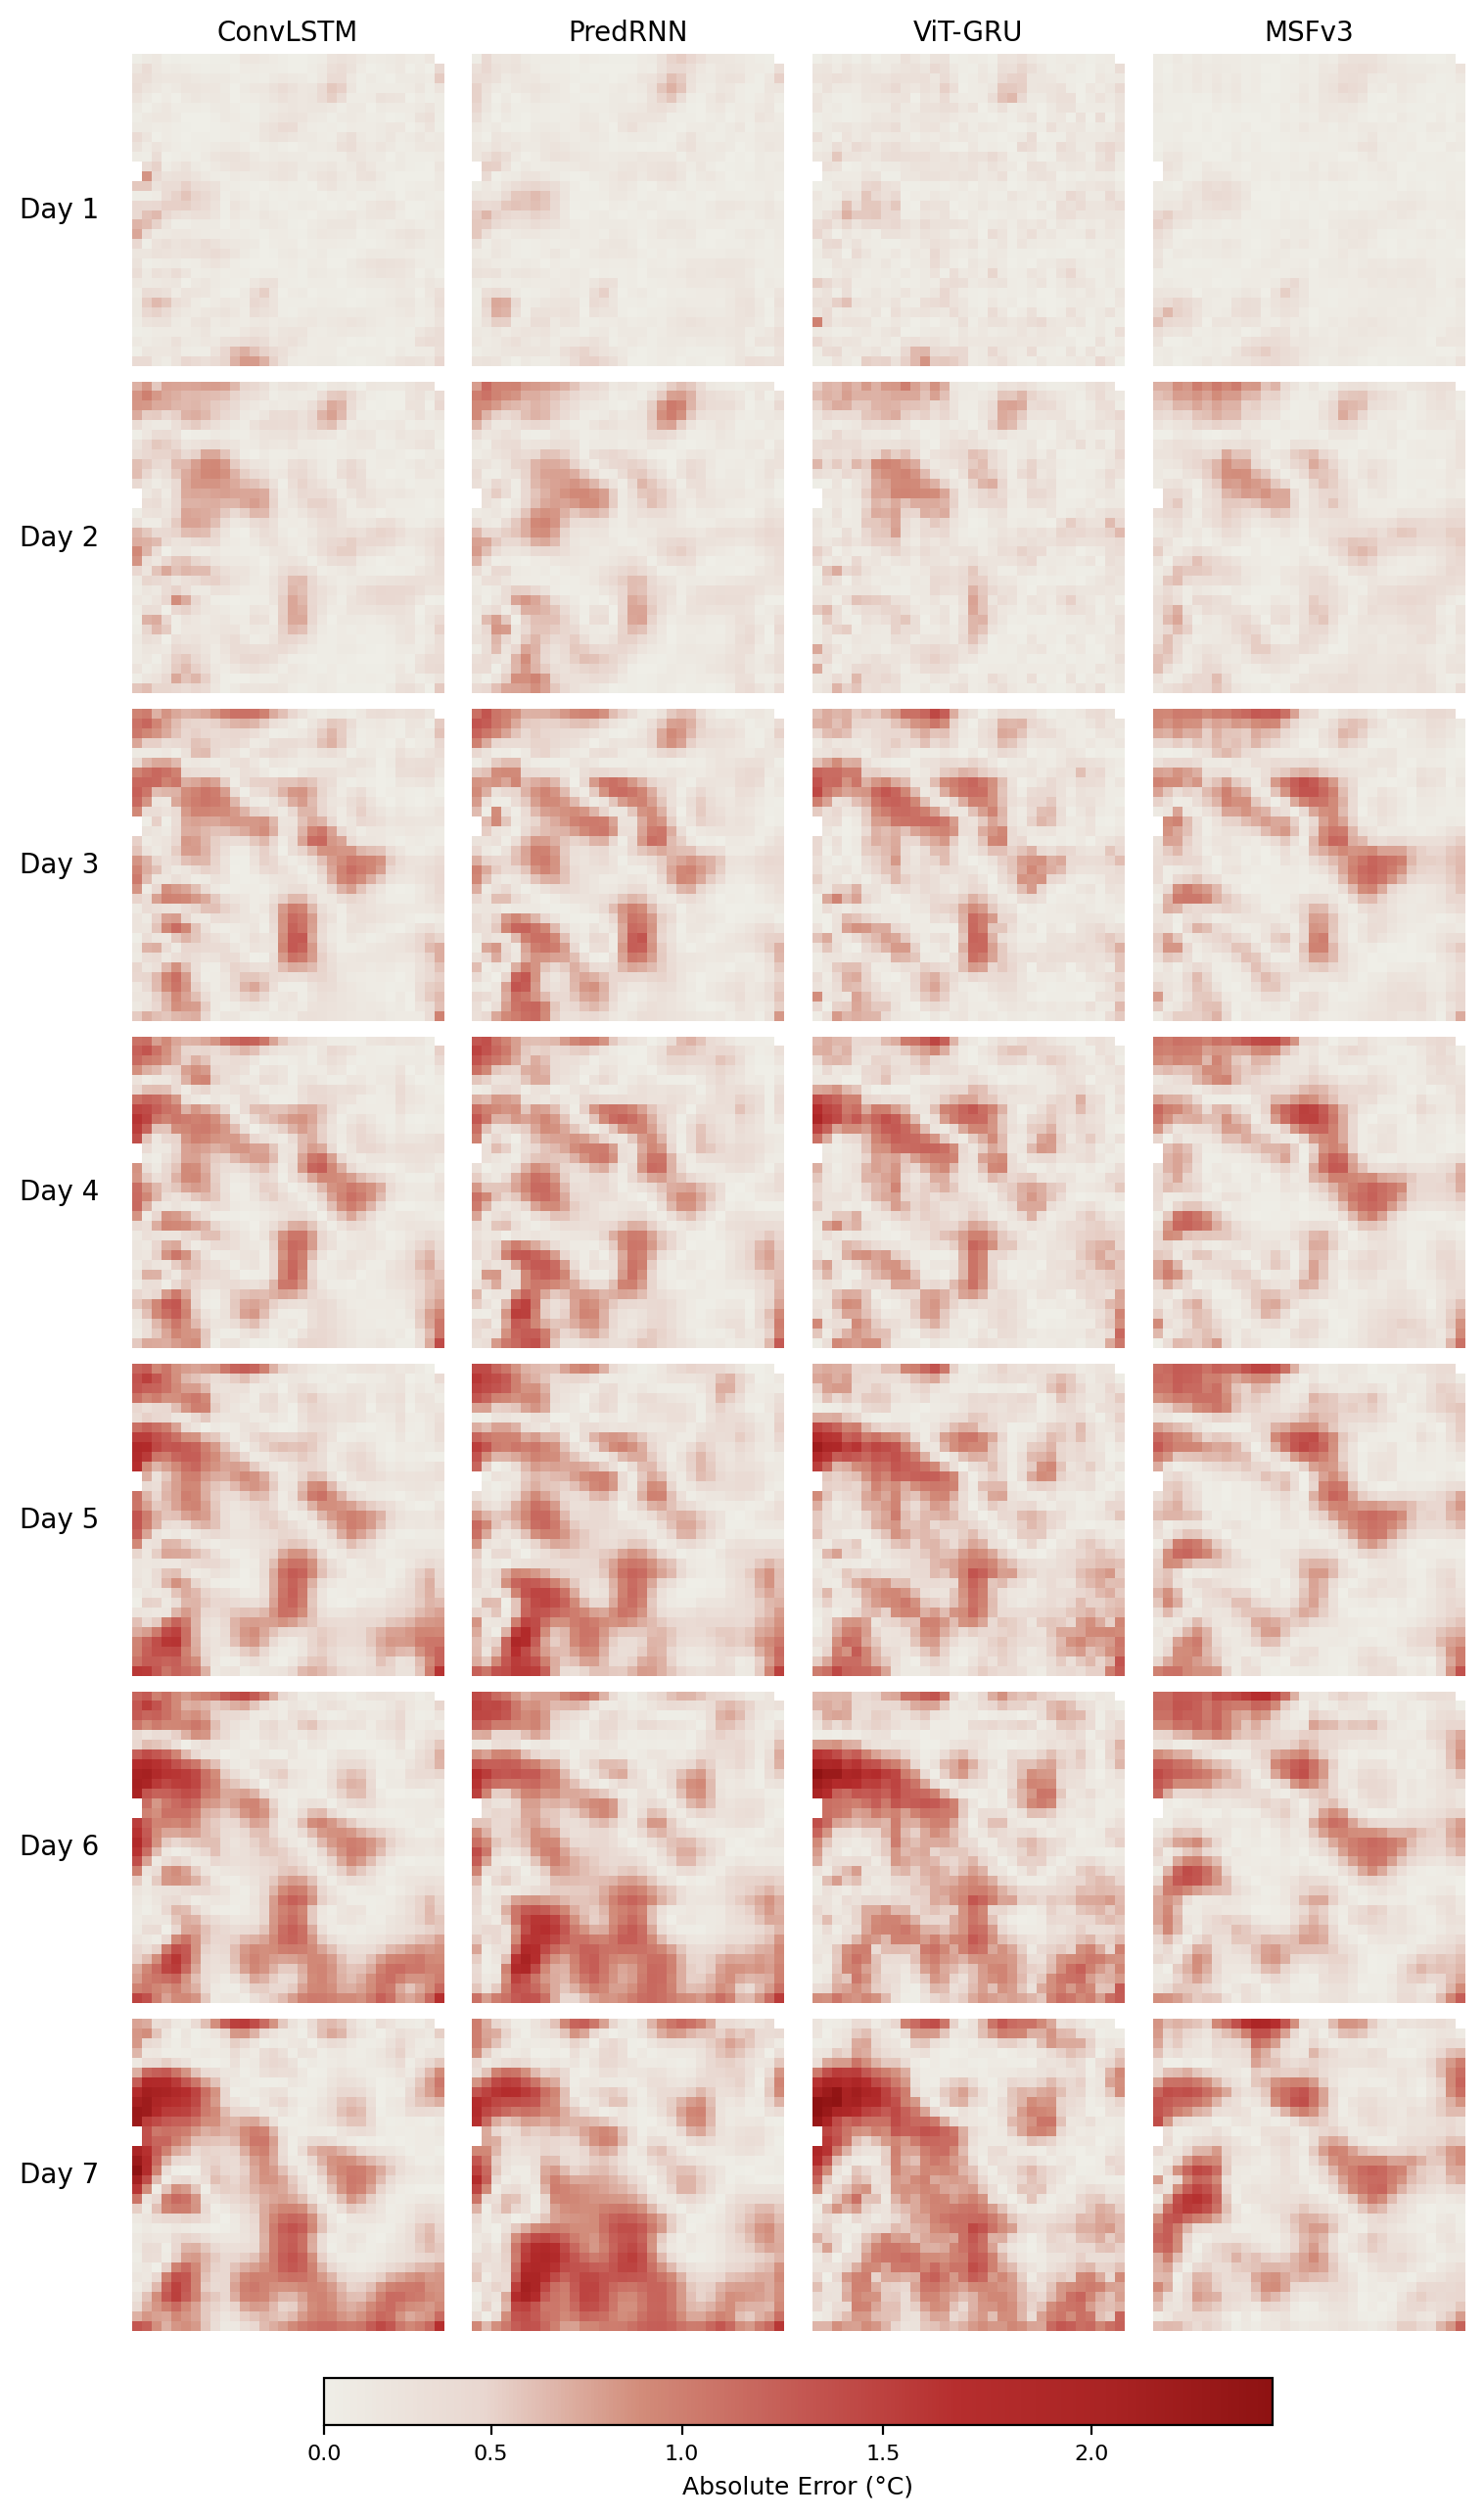

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, LinearSegmentedColormap

# =========================================================
# 0) 설정
# =========================================================
PRED_DIR = "model_comparison"
GT_PATH = os.path.join(PRED_DIR, "ground_truth.npy")
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"

MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

MODEL_NAMES = [
    "ConvLSTM",
    "predrnn",
    "ViT_GRU",
    "msfv3_gdl03",
]
MODEL_LABELS = {
    "ConvLSTM": "ConvLSTM",
    "predrnn": "PredRNN",
    "ViT_GRU": "ViT-GRU",
    "msfv3_gdl03": "MSFv3",
}

SAMPLE_IDX = 71
LEADS_TO_SHOW = [0, 1, 2, 3, 4, 5, 6]

SAVE_FIG = False
SAVE_PATH = os.path.join(PRED_DIR, f"paper_style_error_grid_sample{SAMPLE_IDX}.png")

USE_ABS_ERROR = True
INTERPOLATION = "nearest"
FIG_DPI = 200
MASK_COLOR = "white"
ERROR_GAMMA = 1.1

TITLE_FONTSIZE = 10
DAY_FONTSIZE = 10
CBAR_TICK_FONTSIZE = 8
CBAR_LABEL_FONTSIZE = 9

# =========================================================
# 유틸
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def normalize_spatial_mask(mask, H, W):
    mask = np.asarray(mask)
    mask = np.squeeze(mask)

    if mask.shape == (H, W):
        return mask.astype(bool)

    if mask.ndim >= 2 and mask.shape[-2:] == (H, W):
        while mask.ndim > 2:
            mask = mask[0]
        return mask.astype(bool)

    raise ValueError(f"Mask shape mismatch: got {mask.shape}, expected (*, {H}, {W})")


def apply_mask2d(x2d, mask, fill=np.nan):
    out = np.array(x2d, copy=True)
    out[~mask] = fill
    return out


def make_mae_like_cmap():
    colors = [
        "#efeee7",
        "#e9d7d0",
        "#d28c7a",
        "#c45953",
        "#b62e2e",
        "#a92323",
        "#8e1212",
    ]
    cmap = LinearSegmentedColormap.from_list("soft_green_error_deeper", colors, N=256)
    cmap = cmap.copy()
    cmap.set_bad(color=MASK_COLOR)
    return cmap


# =========================================================
# 데이터 로드
# =========================================================
gt = np.load(GT_PATH)
if gt.ndim != 5:
    raise ValueError(f"GT shape must be (N,T,C,H,W), got {gt.shape}")

gt = denorm_sst(gt)
N, T, C, H, W = gt.shape

mask_raw = np.load(MASK_PATH)
mask = normalize_spatial_mask(mask_raw, H, W)

pred_dict = {}
for model_name in MODEL_NAMES:
    pred_path = os.path.join(PRED_DIR, f"{model_name}_preds.npy")
    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"Prediction file not found: {pred_path}")

    pred = np.load(pred_path)
    if pred.shape != gt.shape:
        raise ValueError(f"{model_name} shape mismatch: pred={pred.shape}, gt={gt.shape}")

    pred_dict[model_name] = denorm_sst(pred)

if not (0 <= SAMPLE_IDX < N):
    raise ValueError(f"SAMPLE_IDX={SAMPLE_IDX} is out of range (0 ~ {N-1})")

for lead in LEADS_TO_SHOW:
    if not (0 <= lead < T):
        raise ValueError(f"Invalid lead {lead} for T={T}")

# =========================================================
# 공통 error range 계산
# =========================================================
err_vmax = 0.0
for model_name in MODEL_NAMES:
    for lead in LEADS_TO_SHOW:
        gt_map = gt[SAMPLE_IDX, lead, 0]
        pred_map = pred_dict[model_name][SAMPLE_IDX, lead, 0]
        err_map = np.abs(pred_map - gt_map)
        vals = err_map[mask]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            err_vmax = max(err_vmax, np.nanmax(vals))

if not np.isfinite(err_vmax) or err_vmax <= 0:
    err_vmax = 1.0

# =========================================================
# Figure 생성
# =========================================================
nrows = len(LEADS_TO_SHOW)
ncols = len(MODEL_NAMES)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(1.95 * ncols, 2.0 * nrows),
    dpi=FIG_DPI
)

if nrows == 1:
    axes = np.expand_dims(axes, axis=0)
if ncols == 1:
    axes = np.expand_dims(axes, axis=1)

cmap = make_mae_like_cmap()
norm = PowerNorm(gamma=ERROR_GAMMA, vmin=0.0, vmax=err_vmax)

im = None

for r, lead in enumerate(LEADS_TO_SHOW):
    for c, model_name in enumerate(MODEL_NAMES):
        gt_map = gt[SAMPLE_IDX, lead, 0]
        pred_map = pred_dict[model_name][SAMPLE_IDX, lead, 0]

        if USE_ABS_ERROR:
            show_map = np.abs(pred_map - gt_map)
        else:
            show_map = pred_map

        show_map = apply_mask2d(show_map, mask)

        im = axes[r, c].imshow(
            show_map,
            norm=norm,
            cmap=cmap,
            origin="lower",
            interpolation=INTERPOLATION
        )

        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])

        for spine in axes[r, c].spines.values():
            spine.set_visible(False)

        if r == 0:
            axes[r, c].set_title(
                MODEL_LABELS.get(model_name, model_name),
                fontsize=TITLE_FONTSIZE,
                pad=5
            )

        if c == 0:
            axes[r, c].set_ylabel(
                f"Day {lead + 1}",
                fontsize=DAY_FONTSIZE,
                rotation=0,
                labelpad=12,   # 28 -> 12 로 줄임
                va="center",
                ha="right"
            )

# 왼쪽/아래 여백도 같이 정리
fig.subplots_adjust(
    left=0.10,
    right=0.985,
    top=0.965,
    bottom=0.10,
    wspace=0.03,
    hspace=0.05
)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.020,
    pad=0.02,
    shrink=0.78   # 이전처럼 길이 줄이기
)

cbar.set_label("Absolute Error (°C)", fontsize=CBAR_LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)

# =========================================================
# 저장 / 출력
# =========================================================
if SAVE_FIG:
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

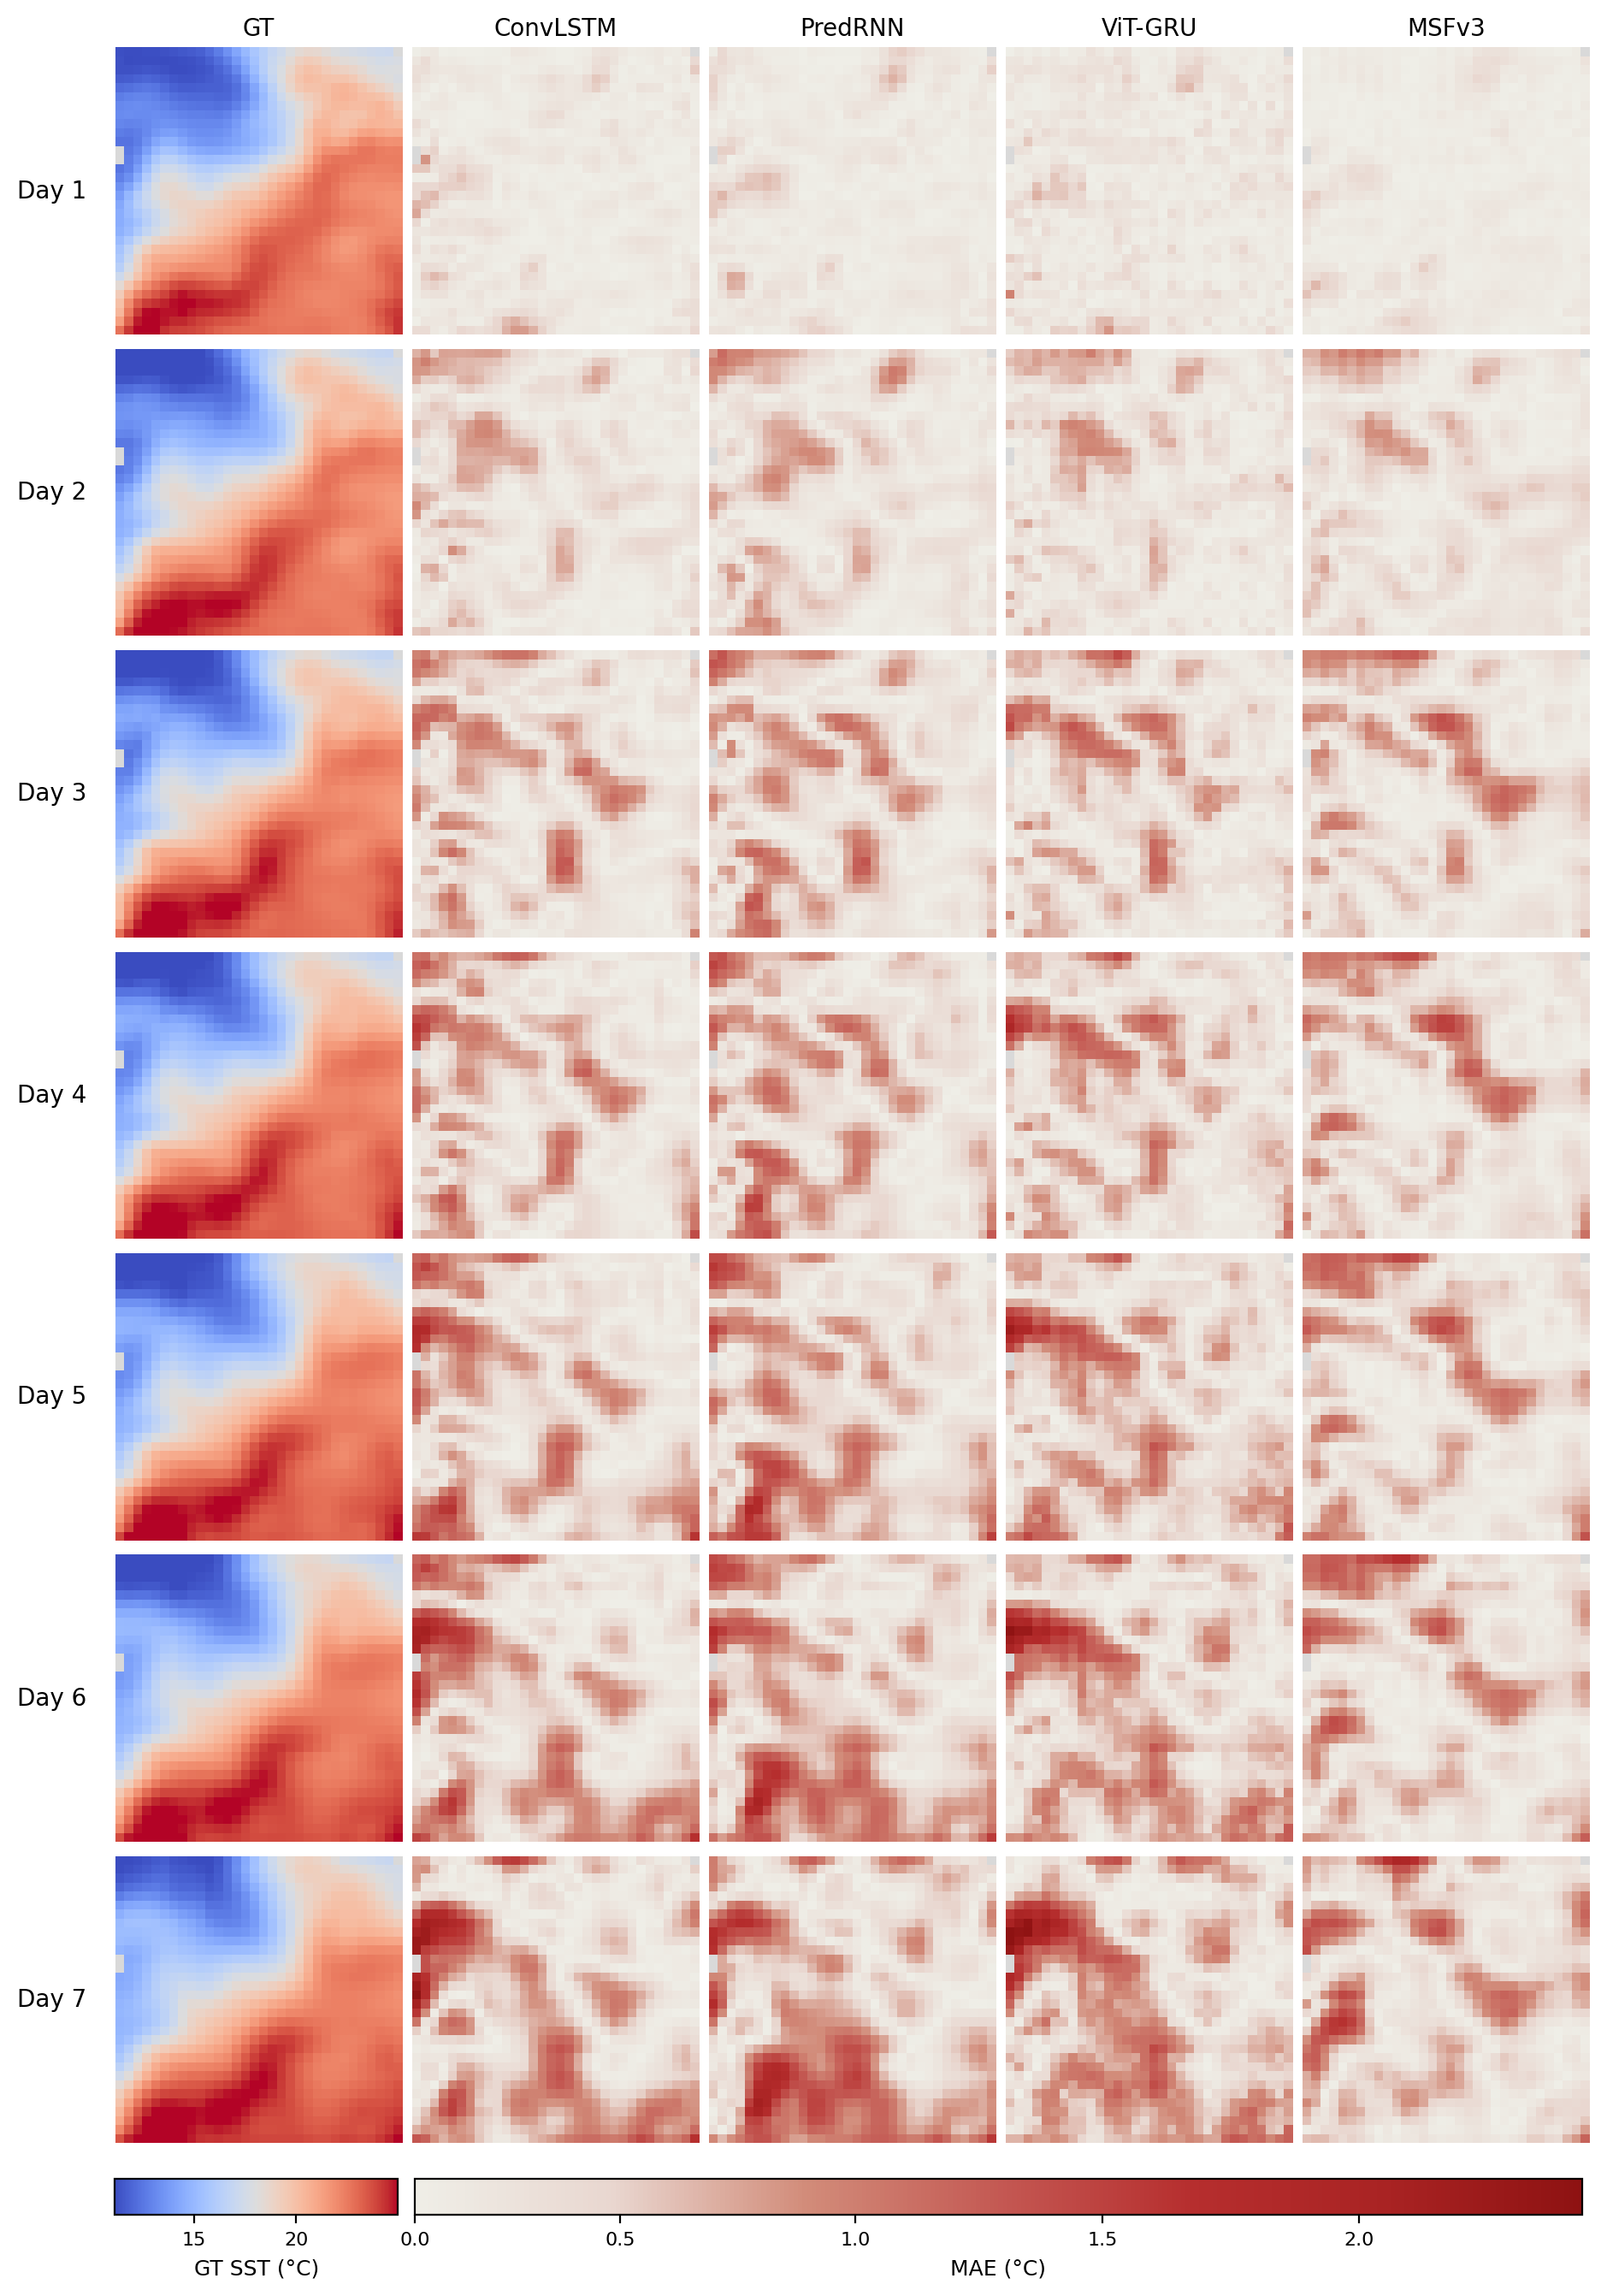

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, LinearSegmentedColormap

# =========================================================
# 0) 설정
# =========================================================
PRED_DIR = "model_comparison"
GT_PATH = os.path.join(PRED_DIR, "ground_truth.npy")
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"

MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

MODEL_NAMES = [
    "ConvLSTM",
    "predrnn",
    "ViT_GRU",
    "msfv3_gdl03",
]
MODEL_LABELS = {
    "ConvLSTM": "ConvLSTM",
    "predrnn": "PredRNN",
    "ViT_GRU": "ViT-GRU",
    "msfv3_gdl03": "MSFv3",
}

SAMPLE_IDX = 71
LEADS_TO_SHOW = [0, 1, 2, 3, 4, 5, 6]

SAVE_FIG = True
SAVE_PATH = (f"result_comparison_{SAMPLE_IDX}.png")

USE_ABS_ERROR = True
INTERPOLATION = "nearest"
FIG_DPI = 200
MASK_COLOR = "#D9D9D9"
ERROR_GAMMA = 1.1

TITLE_FONTSIZE = 10
DAY_FONTSIZE = 10
CBAR_TICK_FONTSIZE = 8
CBAR_LABEL_FONTSIZE = 9

SHOW_GT_COLUMN = True

# =========================================================
# 유틸
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def normalize_spatial_mask(mask, H, W):
    mask = np.asarray(mask)
    mask = np.squeeze(mask)

    if mask.shape == (H, W):
        return mask.astype(bool)

    if mask.ndim >= 2 and mask.shape[-2:] == (H, W):
        while mask.ndim > 2:
            mask = mask[0]
        return mask.astype(bool)

    raise ValueError(f"Mask shape mismatch: got {mask.shape}, expected (*, {H}, {W})")


def apply_mask2d(x2d, mask, fill=np.nan):
    out = np.array(x2d, copy=True)
    out[~mask] = fill
    return out


def make_mae_like_cmap():
    colors = [
        "#efeee7",
        "#e9d7d0",
        "#d28c7a",
        "#c45953",
        "#b62e2e",
        "#a92323",
        "#8e1212",
    ]
    cmap = LinearSegmentedColormap.from_list("soft_red_error_deeper", colors, N=256)
    cmap = cmap.copy()
    cmap.set_bad(color=MASK_COLOR)
    return cmap


def make_gt_cmap():
    cmap = plt.cm.coolwarm.copy()
    cmap.set_bad(color=MASK_COLOR)
    return cmap


# =========================================================
# 데이터 로드
# =========================================================
gt = np.load(GT_PATH)
if gt.ndim != 5:
    raise ValueError(f"GT shape must be (N,T,C,H,W), got {gt.shape}")

gt = denorm_sst(gt)
N, T, C, H, W = gt.shape

mask_raw = np.load(MASK_PATH)
mask = normalize_spatial_mask(mask_raw, H, W)

pred_dict = {}
for model_name in MODEL_NAMES:
    pred_path = os.path.join(PRED_DIR, f"{model_name}_preds.npy")
    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"Prediction file not found: {pred_path}")

    pred = np.load(pred_path)
    if pred.shape != gt.shape:
        raise ValueError(f"{model_name} shape mismatch: pred={pred.shape}, gt={gt.shape}")

    pred_dict[model_name] = denorm_sst(pred)

if not (0 <= SAMPLE_IDX < N):
    raise ValueError(f"SAMPLE_IDX={SAMPLE_IDX} is out of range (0 ~ {N-1})")

for lead in LEADS_TO_SHOW:
    if not (0 <= lead < T):
        raise ValueError(f"Invalid lead {lead} for T={T}")

# =========================================================
# 공통 range 계산
# =========================================================
err_vmax = 0.0
for model_name in MODEL_NAMES:
    for lead in LEADS_TO_SHOW:
        gt_map = gt[SAMPLE_IDX, lead, 0]
        pred_map = pred_dict[model_name][SAMPLE_IDX, lead, 0]
        err_map = np.abs(pred_map - gt_map)
        vals = err_map[mask]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            err_vmax = max(err_vmax, np.nanmax(vals))

if not np.isfinite(err_vmax) or err_vmax <= 0:
    err_vmax = 1.0

gt_vals_all = []
for lead in LEADS_TO_SHOW:
    vals = gt[SAMPLE_IDX, lead, 0][mask]
    vals = vals[np.isfinite(vals)]
    if len(vals) > 0:
        gt_vals_all.append(vals)

if len(gt_vals_all) == 0:
    gt_vmin, gt_vmax = 0.0, 1.0
else:
    gt_vals_all = np.concatenate(gt_vals_all)
    gt_vmin = np.percentile(gt_vals_all, 2)
    gt_vmax = np.percentile(gt_vals_all, 98)
    if gt_vmin >= gt_vmax:
        gt_vmin = np.min(gt_vals_all)
        gt_vmax = np.max(gt_vals_all)

# =========================================================
# Figure 생성
# =========================================================
nrows = len(LEADS_TO_SHOW)
n_model_cols = len(MODEL_NAMES)
ncols = n_model_cols + 1 if SHOW_GT_COLUMN else n_model_cols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(1.95 * ncols, 2.0 * nrows),
    dpi=FIG_DPI
)

if nrows == 1:
    axes = np.expand_dims(axes, axis=0)
if ncols == 1:
    axes = np.expand_dims(axes, axis=1)

err_cmap = make_mae_like_cmap()
err_norm = PowerNorm(gamma=ERROR_GAMMA, vmin=0.0, vmax=err_vmax)

gt_cmap = make_gt_cmap()

im_gt = None
im_err = None

for r, lead in enumerate(LEADS_TO_SHOW):
    col_offset = 0

    if SHOW_GT_COLUMN:
        gt_show = apply_mask2d(gt[SAMPLE_IDX, lead, 0], mask)

        im_gt = axes[r, 0].imshow(
            gt_show,
            cmap=gt_cmap,
            vmin=gt_vmin,
            vmax=gt_vmax,
            origin="lower",
            interpolation=INTERPOLATION
        )

        axes[r, 0].set_xticks([])
        axes[r, 0].set_yticks([])

        for spine in axes[r, 0].spines.values():
            spine.set_visible(False)

        if r == 0:
            axes[r, 0].set_title("GT", fontsize=TITLE_FONTSIZE, pad=5)

        axes[r, 0].set_ylabel(
            f"Day {lead + 1}",
            fontsize=DAY_FONTSIZE,
            rotation=0,
            labelpad=12,
            va="center",
            ha="right"
        )

        col_offset = 1

    for c, model_name in enumerate(MODEL_NAMES):
        gt_map = gt[SAMPLE_IDX, lead, 0]
        pred_map = pred_dict[model_name][SAMPLE_IDX, lead, 0]

        if USE_ABS_ERROR:
            show_map = np.abs(pred_map - gt_map)
        else:
            show_map = pred_map

        show_map = apply_mask2d(show_map, mask)

        ax = axes[r, c + col_offset]
        im_err = ax.imshow(
            show_map,
            norm=err_norm,
            cmap=err_cmap,
            origin="lower",
            interpolation=INTERPOLATION
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        if r == 0:
            ax.set_title(
                MODEL_LABELS.get(model_name, model_name),
                fontsize=TITLE_FONTSIZE,
                pad=5
            )

# =========================================================
# 여백 조정
# =========================================================
fig.subplots_adjust(
    left=0.10,
    right=0.985,
    top=0.965,
    bottom=0.09,   # 0.14 -> 0.09 : 컬러바와 그림 사이 여백 축소
    wspace=0.03,
    hspace=0.05
)

# =========================================================
# 컬러바
# - 두 bar의 높이는 동일
# - GT bar는 짧게
# - Error bar는 더 길게
# - 전체적으로 그림에 더 가깝게
# =========================================================
bar_y = 0.060   # 너무 아래였으면 이 값을 올리기
bar_h = 0.015   # 기존보다 더 얇게

# [left, bottom, width, height]
cax_gt  = fig.add_axes([0.10, bar_y, 0.17, bar_h])   # GT: 짧게
cax_err = fig.add_axes([0.28, bar_y, 0.70, bar_h])   # Error: 더 길게

cbar_gt = fig.colorbar(im_gt, cax=cax_gt, orientation="horizontal")
cbar_gt.set_label("GT SST (°C)", fontsize=CBAR_LABEL_FONTSIZE)
cbar_gt.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)

cbar_err = fig.colorbar(im_err, cax=cax_err, orientation="horizontal")
cbar_err.set_label("MAE (°C)", fontsize=CBAR_LABEL_FONTSIZE)
cbar_err.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)

# =========================================================
# 저장 / 출력
# =========================================================
if SAVE_FIG:
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)